In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
from cvxpy import psd_wrap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from cvxpy.atoms.affine.wraps import psd_wrap
from sklearn.covariance import LedoitWolf
import seaborn as sns
import pickle
from plot_functions import plot_te_carbon_by_sector, plot_origin_vs_opt_weights_comparison, plot_te_carbon_heatmap
from tabulate import tabulate
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
import shutil
import os
from joblib import Parallel, delayed

| Term         | What to Use                                                     |
| ------------ | --------------------------------------------------------------- |
| `w_b_sector` | Benchmark weights **within the sector**, normalized to sum to 1 |
| `Σ_sector`   | Covariance matrix of sector constituents                        |
| `c_sector`   | Carbon intensities of sector companies                          |
| `w`          | Optimization variable: weights in sector                        |
| Constraints  | All operate **within** the sector universe                      |


# Missing Data and Scope emissions composition

In [2]:
# Load data
df = pd.read_excel("Data/out-of-sample/dataset_comp_1221.xlsx")
df.isna().any()

Unnamed: 0                       False
NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day Dec 21           False
Price last day Dec 21            False
Scope 1                          False
Scope 2                          False
Scope 3                          False
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                 False
AnonID                            True
Manually Imputed Scope 2          True
Manually Imputed Scope 1          True
Manually Imputed Scope 3          True
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials               False
Sector_Information Technology    False
Sector_Materials         

In [3]:
# Columns of interest
auto_impute_flags = ['Scope 1 Imputed', 'Scope 2 Imputed', 'Scope 3 Imputed']
manual_impute_flags = ['Manually Imputed Scope 1', 'Manually Imputed Scope 2', 'Manually Imputed Scope 3']

# Build the summary table
summary_rows = []

for sector, group in df.groupby('GICS Sector'):
    n_stocks = len(group)
    row = {
        'Sector': sector,
        'Number of Stocks': n_stocks
    }

    # Automatically imputed (Scope 1/2/3)
    for col in auto_impute_flags:
        count = group[col].fillna(False).sum()
        scope = col.split()[1]   # e.g. "1" from "Scope 1 Imputed"
        row[f'Auto Imputed Scope {scope} Count'] = count
        row[f'Auto Imputed Scope {scope} %'] = count / n_stocks * 100

    # Manually imputed (Scope 1/2/3)
    for col in manual_impute_flags:
        count = group[col].fillna(False).sum()
        scope = col.split()[-1] # e.g. "1" from "Manually Imputed Scope 1"
        row[f'Manual Imputed Scope {scope} Count'] = count
        row[f'Manual Imputed Scope {scope} %'] = count / n_stocks * 100

    summary_rows.append(row)

sector_imputation_summary = pd.DataFrame(summary_rows)
sector_imputation_summary = sector_imputation_summary.sort_values("Sector").reset_index(drop=True)

# Round all percentage columns to integers
percentage_cols = [col for col in sector_imputation_summary.columns if '%' in col]
sector_imputation_summary[percentage_cols] = sector_imputation_summary[percentage_cols].round(0).astype('Int64')

# Create 'Missing Scope' = max imputed (auto or manual) across scopes
sector_imputation_summary["Missing Scope Count"] = sector_imputation_summary[
    ["Auto Imputed Scope 1 Count", "Auto Imputed Scope 2 Count", "Auto Imputed Scope 3 Count"]
].max(axis=1) + sector_imputation_summary[
    ["Manual Imputed Scope 1 Count", "Manual Imputed Scope 2 Count", "Manual Imputed Scope 3 Count"]
].max(axis=1)

sector_imputation_summary["Missing Scope (%)"] = (
    sector_imputation_summary["Missing Scope Count"] / sector_imputation_summary["Number of Stocks"] * 100
).round(0).astype('Int64')

# Define the new column order
columns_order = ['Sector', 'Number of Stocks', 'Missing Scope Count', 'Missing Scope (%)'] + \
                [col for col in sector_imputation_summary.columns if col not in ['Sector', 'Number of Stocks', 'Missing Scope Count', 'Missing Scope (%)']]

sector_imputation_summary = sector_imputation_summary[columns_order].sort_values("Missing Scope (%)", ascending=False).reset_index(drop=True)

sector_imputation_summary

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_907/1918135485.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count = group[col].fillna(False).sum()
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_907/1918135485.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count = group[col].fillna(False).sum()


,Sector,Number of Stocks,Missing Scope Count,Missing Scope (%),Auto Imputed Scope 1 Count,Auto Imputed Scope 1 %,Auto Imputed Scope 2 Count,Auto Imputed Scope 2 %,Auto Imputed Scope 3 Count,Auto Imputed Scope 3 %,Manual Imputed Scope 1 Count,Manual Imputed Scope 1 %,Manual Imputed Scope 2 Count,Manual Imputed Scope 2 %,Manual Imputed Scope 3 Count,Manual Imputed Scope 3 %
0,Energy,21,10.0,48,0.0,0,0.0,0,10.0,48,0.0,0,0.0,0,0.0,0
1,Health Care,63,25.0,40,3.0,5,3.0,5,24.0,38,1.0,2,1.0,2,1.0,2
2,Industrials,74,27.0,36,3.0,4,3.0,4,25.0,34,2.0,3,2.0,3,1.0,1
3,Consumer Discretionary,56,16.0,29,1.0,2,2.0,4,14.0,25,2.0,4,2.0,4,2.0,4
4,Communication Services,23,6.0,26,3.0,13,3.0,13,5.0,22,1.0,4,1.0,4,1.0,4
5,Consumer Staples,36,9.0,25,0.0,0,0.0,0,6.0,17,3.0,8,3.0,8,1.0,3
6,Financials,75,19.0,25,5.0,7,5.0,7,14.0,19,5.0,7,5.0,7,5.0,7
7,Real Estate,29,7.0,24,1.0,3,1.0,3,6.0,21,1.0,3,0.0,0,0.0,0
8,Information Technology,64,14.0,22,3.0,5,3.0,5,13.0,20,1.0,2,1.0,2,1.0,2
9,Materials,28,4.0,14,0.0,0,0.0,0,4.0,14,0.0,0,0.0,0,0.0,0


In [4]:
def sector_aggregates(df, top_weight_pct=0.2):
    results = []

    total_mcap = df["float_mcap"].sum()  # total benchmark market cap

    for sector, g in df.groupby("GICS Sector"):
        # absolute totals
        s1 = g["Scope 1"].sum()
        s2 = g["Scope 2"].sum()
        s3 = g["Scope 3"].sum()
        total_emissions = g["Scope 1+2+3"].sum()

        # percentages of each scope
        pct_s1, pct_s2, pct_s3 = s1/total_emissions, s2/total_emissions, s3/total_emissions

        # top 5 emitters in sector
        top5 = g.nlargest(5, "Scope 1+2+3")["Scope 1+2+3"].sum() / total_emissions

        # emissions captured within top X% of sector weights
        g_sorted = g.sort_values("weight_in_sector", ascending=False).copy()
        g_sorted["cum_weight"] = g_sorted["weight_in_sector"].cumsum()
        emissions_top_weight = g_sorted.loc[g_sorted["cum_weight"] <= top_weight_pct, "Scope 1+2+3"].sum()
        pct_emissions_top_weight = emissions_top_weight / total_emissions

        # sector market cap as percentage of benchmark
        sector_mcap = g["float_mcap"].sum()
        sector_mcap_pct = sector_mcap / total_mcap

        results.append({
            "Sector": sector,
            "Scope 1 sum": s1,
            "Scope 2 sum": s2,
            "Scope 3 sum": s3,
            "Scope 1+2+3 absolute": total_emissions,
            "% Scope 1": pct_s1,
            "% Scope 2": pct_s2,
            "% Scope 3": pct_s3,
            "% Top 5 emitters": top5,
            f"% Emissions in Top {int(top_weight_pct*100)}% Weight": pct_emissions_top_weight,
            "Avg Scope 1+2+3": g["Scope 1+2+3"].mean(),
            "Avg Scope 1": g["Scope 1"].mean(),
            "Avg Scope 2": g["Scope 2"].mean(),
            "Avg Scope 3": g["Scope 3"].mean(),
            "Var Scope 1": g["Scope 1"].std(),
            "Var Scope 2": g["Scope 2"].std(),
            "Var Scope 3": g["Scope 3"].std(),
            "Avg Carbon Intensity": g["Carbon Intensity"].mean(),
            "Aggregate Carbon Intensity": total_emissions / g["Revenue"].sum(),
            "Sector Market Cap %": sector_mcap_pct
        })

    return pd.DataFrame(results)

In [5]:
pd.options.display.float_format = '{:,.2f}'.format
sector_emissions_summary = sector_aggregates(df)
pct_cols = ["% Scope 1", "% Scope 2", "% Scope 3", "% Top 5 emitters", 
            "% Emissions in Top 20% Weight", "Sector Market Cap %"]

sector_emissions_summary[pct_cols] = sector_emissions_summary[pct_cols].applymap(lambda x: f"{x:.1%}")

round_cols = ["Avg Scope 1+2+3", "Avg Scope 1", "Avg Scope 2", "Avg Scope 3",
              "Var Scope 1", "Var Scope 2", "Var Scope 3",
              "Avg Carbon Intensity", "Aggregate Carbon Intensity"]

sector_emissions_summary[round_cols] = sector_emissions_summary[round_cols].round(2)
def human_format(num):
    for unit in ['', 'K', 'M', 'B', 'T']:
        if abs(num) < 1000:
            return f"{num:.1f}{unit}"
        num /= 1000
    return f"{num:.1f}P"

num_cols = ["Scope 1 sum","Scope 2 sum","Scope 3 sum","Scope 1+2+3 absolute"]
sector_emissions_summary[num_cols] = sector_emissions_summary[num_cols].applymap(human_format)
sector_emissions_summary

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_907/297281412.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sector_emissions_summary[pct_cols] = sector_emissions_summary[pct_cols].applymap(lambda x: f"{x:.1%}")
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_907/297281412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sector_emissions_summary[num_cols] = sector_emissions_summary[num_cols].applymap(human_format)


,Sector,Scope 1 sum,Scope 2 sum,Scope 3 sum,Scope 1+2+3 absolute,% Scope 1,% Scope 2,% Scope 3,% Top 5 emitters,% Emissions in Top 20% Weight,Avg Scope 1+2+3,Avg Scope 1,Avg Scope 2,Avg Scope 3,Var Scope 1,Var Scope 2,Var Scope 3,Avg Carbon Intensity,Aggregate Carbon Intensity,Sector Market Cap %
0,Communication Services,31.6M,36.0M,408.6M,476.3M,6.6%,7.6%,85.8%,90.3%,0.0%,"20,707,121.34","1,373,772.08","1,566,483.95","17,766,865.31","5,722,700.32","2,404,228.28","67,630,327.74",0.07,0.03,10.1%
1,Consumer Discretionary,41.7M,26.1M,1.2B,1.3B,3.2%,2.0%,94.8%,74.8%,0.0%,"23,209,298.28","745,460.61","466,887.57","21,996,950.10","2,224,956.74","871,008.21","67,082,869.16",0.56,0.63,12.4%
2,Consumer Staples,45.5M,35.8M,1.2B,1.3B,3.5%,2.8%,93.7%,67.6%,13.8%,"35,631,662.71","1,263,798.46","995,762.53","33,372,101.72","2,572,309.95","1,715,406.02","62,050,860.07",0.59,0.62,6.5%
3,Energy,327.1M,44.8M,1.9B,2.3B,14.5%,2.0%,83.5%,60.8%,0.0%,"107,405,619.84","15,578,087.19","2,134,062.24","89,693,470.41","22,719,013.48","2,532,132.70","100,883,621.76",3.11,1.76,2.7%
4,Financials,42.7M,31.1M,1.3B,1.4B,3.0%,2.2%,94.7%,89.3%,0.1%,"18,699,672.19","569,032.29","414,731.06","17,715,908.84","2,785,961.47","1,450,768.90","65,402,965.96",0.96,0.07,13.2%
5,Health Care,32.3M,20.5M,626.1M,678.9M,4.8%,3.0%,92.2%,73.0%,4.9%,"10,776,169.70","512,985.56","324,962.32","9,938,221.81","2,307,475.52","936,956.69","34,037,476.77",0.11,0.07,13.4%
6,Industrials,267.3M,30.9M,2.9B,3.2B,8.3%,1.0%,90.7%,65.6%,3.1%,"43,276,838.25","3,612,136.84","417,063.46","39,247,637.95","8,182,117.29","1,178,291.62","139,092,080.83",1.94,0.33,8.1%
7,Information Technology,61.2M,42.0M,734.6M,837.8M,7.3%,5.0%,87.7%,72.0%,0.0%,"13,090,601.02","955,928.93","656,918.89","11,477,753.20","4,788,094.56","1,599,457.02","42,398,554.98",0.28,0.11,25.6%
8,Materials,142.4M,68.3M,450.3M,661.0M,21.5%,10.3%,68.1%,61.8%,9.6%,"23,605,698.60","5,085,633.86","2,438,385.08","16,081,679.66","6,957,153.23","4,310,354.92","23,998,126.44",1.48,1.46,2.6%
9,Real Estate,7.0M,17.2M,273.1M,297.2M,2.3%,5.8%,91.9%,93.5%,1.8%,"10,249,363.84","239,800.45","592,327.34","9,417,236.06","897,272.58","1,522,272.20","39,366,551.05",0.28,0.24,2.8%


# TE - CARBON FRONTIERS OPTIMIZATION

In [6]:
import shutil
shutil.rmtree("cache/1221")  

In [7]:
# --- Utility functions ---
def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_shrink_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    Sigma_reg = Sigma_shrink + 1e-5 * np.eye(Sigma_shrink.shape[0])
    return nearest_psd(Sigma_reg), lw.shrinkage_

def run_sector_optimisation(sector_name, sector, R, cov_type="raw", cache_dir="cache"):
    os.makedirs(cache_dir, exist_ok=True)
    cache_file = f"{cache_dir}/{sector_name}_{cov_type}.pkl"

    # --- Load from cache if exists ---
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            return pickle.load(f)

    # --- Inputs ---
    w_bench = sector['weight_in_sector'].values
    c_vec = sector['Carbon Intensity'].values
    assert np.isclose(w_bench.sum(), 1.0)
    assert not np.isnan(c_vec).any()

    R_clean = R.drop(columns=['Date']).dropna()
    stock_labels = R_clean.columns

    # --- Choose covariance ---
    if cov_type == "raw":
        Sigma = sigma_raw_fn(R_clean)
        shrinkage_alpha = None
    elif cov_type == "shrink":
        Sigma, shrinkage_alpha = sigma_shrink_fn(R_clean)
    else:
        raise ValueError("cov_type must be 'raw' or 'shrink'")

    eigvals = np.linalg.eigvalsh(Sigma)
    smallest_eigs= np.sort(eigvals)[:5]
    rank = np.linalg.matrix_rank(Sigma)
    num_features = Sigma.shape[1]
    N = len(w_bench)

    # --- Optimisation loop ---
    te_caps_annual = np.linspace(0.002, 0.05, 100)
    
    # Ensure 0.02 (2%) is included
    if not np.isclose(te_caps_annual, 0.02).any():
        te_caps_annual = np.sort(np.append(te_caps_annual, 0.02))

    tracking_errors, carbon_reductions, weights_by_te = [], [], []

    for te_annual in te_caps_annual:
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(cp.Minimize(c_vec @ w), constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if prob.status not in ["optimal", "optimal_inaccurate"] or w.value is None:
            continue

        w_opt = w.value
        diff = w_opt - w_bench
        te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
        carbon_b = w_bench @ c_vec
        carbon_opt = w_opt @ c_vec
        reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100

        tracking_errors.append(te_real * 10000)
        carbon_reductions.append(reduction_pct)
        weights_by_te.append(w_opt)

    # --- Summary stats ---
    tracking_errors_np = np.array(tracking_errors)
    carbon_reductions_np = np.array(carbon_reductions)
    start_red, end_red = carbon_reductions_np[0], carbon_reductions_np[-1]
    idx_2pct = np.argmin(np.abs(tracking_errors_np - 200))
    reduction_at_2pct = carbon_reductions_np[idx_2pct]

    diagnostics = {
        "Sector": sector_name,
        "Num Features": num_features,
        "Covariance": cov_type,
        "Rank": rank,
        "Min_Eigval1": smallest_eigs[0],
        "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
        "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
        "Low Rank?": rank < num_features,
        "Not PSD?": eigvals.min() < -1e-6,
        "Shrinkage Alpha": shrinkage_alpha,
        "Start Reduction (%)": round(start_red, 2),
        "End Reduction (%)": round(end_red, 2),
        "Gain (%)": round(end_red - start_red, 2),
        "Reduction @2% TE (%)": round(reduction_at_2pct, 2),
    }

    result = {
        "sector_name": sector_name,
        "cov_type": cov_type,
        "diagnostics": diagnostics,
        "weights_by_te": weights_by_te,
        "tracking_errors": tracking_errors,
        "carbon_reductions": carbon_reductions,
        "w_bench": w_bench,                # add benchmark weights
        "stock_labels": list(stock_labels) # add stock labels
    }

    # --- Save to cache ---
    with open(cache_file, "wb") as f:
        pickle.dump(result, f)
    print(tracking_errors)
    return result

In [8]:
data = pd.read_excel("Data/out-of-sample/dataset_comp_1221.xlsx")
log_returns_all = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_1221.xlsx", sheet_name=None)
regularisation_diagnostics = []
results = []

for sector_name in data['GICS Sector'].unique():
    sector = data[data['GICS Sector'] == sector_name]
    R = log_returns_all[sector_name]

    # --- Raw optimisation ---
    res_raw = run_sector_optimisation(sector_name, sector, R, cov_type="raw", cache_dir="cache/1221")
    results.append(res_raw)


    # --- Shrinkage optimisation ---
    res_shrink = run_sector_optimisation(sector_name, sector, R, cov_type="shrink", cache_dir="cache/1221")
    results.append(res_shrink)

# Combine into DataFrame
diagnostics_df = pd.DataFrame([r["diagnostics"] for r in results])
print(diagnostics_df)


# --- Build one combined dictionary of all optimisation results ---
combined_results = {
    r["sector_name"]: {
        "cov_type": r["cov_type"],
        "diagnostics": r["diagnostics"],
        "weights_by_te": r["weights_by_te"],
        "tracking_errors": r["tracking_errors"],
        "carbon_reductions": r["carbon_reductions"],
        "w_bench": r.get("w_bench"),           # ✅ benchmark weights
        "stock_labels": r.get("stock_labels"), # ✅ stock labels
    }
    for r in results
}

# --- Save to single pickle file ---
output_file = "Data/out-of-sample/optimal_portfolios_all_te_1221.pkl"
with open(output_file, "wb") as f:
    pickle.dump(combined_results, f)

print(f"Combined results saved to {output_file}")

[20.00026078141221, 24.849275341934185, 29.69736261182947, 34.54655822592876, 39.39568852976194, 44.24295037734849, 49.10855276770406, 53.94163055733659, 58.7889373114643, 63.6374665063134, 68.48631224267116, 73.33462456076288, 78.19099560694964, 83.0365523823635, 87.88134898007297, 92.72767161125213, 97.57668598034633, 102.4253511546058, 107.27563741129427, 112.12735723618778, 116.97278477281613, 121.8191273290255, 126.66819631927096, 131.52146611387087, 136.37792757953758, 141.21270274477152, 146.0669633240111, 150.9101626096998, 155.7649487427295, 160.61407929914918, 165.45994477897622, 170.31635719116258, 175.15455533658294, 180.0004480852274, 184.8557444200926, 189.6982110006358, 194.54608552176893, 199.39433851671578, 200.0047544503979, 204.2482099314712, 209.09202895669554, 213.94253220943645, 218.78920482598318, 223.63869319614096, 228.4883691855072, 233.34100837014287, 238.1909255899198, 243.03142169163368, 247.88695596522405, 252.7277459005284, 257.57930004280854, 262.4245327

/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[20.006925286458642, 24.85796479345704, 29.707822456898, 34.54895650864446, 39.4084486254381, 44.2603490278608, 49.09263396829544, 53.93417742699333, 58.79059320777273, 63.646082188122946, 68.49471733252378, 73.33525194677883, 78.1813348493036, 83.03092324551208, 87.87802929155826, 92.72743798478065, 97.57875731856076, 102.42430041913858, 107.2732392714317, 112.12479791636872, 116.97284671044945, 121.81612581186806, 126.66438604890598, 131.5142372015061, 136.36380505064815, 141.20821446957405, 146.06195287582585, 150.90797747520426, 155.75673882861525, 160.6021295389688, 165.45455730913142, 170.30440406377713, 175.15168915013038, 179.9999907070484, 184.85087815568434, 189.69748747068752, 194.54652058496322, 199.39295764790953, 200.00057870406155, 204.24304875386926, 209.1062715741681, 213.96581955920252, 218.7942348936929, 223.6430267680962, 228.4874658306882, 233.33637390187945, 238.1801608562638, 243.02598417334707, 247.87719409845747, 252.7254347649071, 257.57464400741196, 262.42607

In [9]:
with open("Data/out-of-sample/optimal_portfolios_all_te_1221.pkl", "rb") as f:
    optimal_portfolios_all_te = pickle.load(f)

Extracting the optimal portfolio weights at 2% TE:

In [10]:
TARGET_TE_BPS = 200
optimal_portfolios_shrink_2_TE = {}

for sector, info in optimal_portfolios_all_te.items():
    te_list = np.array(info["tracking_errors"])
    weights_list = info["weights_by_te"]

    if len(te_list) == 0:
        continue

    # --- find index of TE closest to 200 bps ---
    idx_closest = np.argmin(np.abs(te_list - TARGET_TE_BPS))
    te_closest = te_list[idx_closest]
    w_opt = weights_list[idx_closest]

    # --- build dictionary in shrink-style format ---
    optimal_portfolios_shrink_2_TE[sector] = {
        "cov_type": info["cov_type"],
        "diagnostics": info["diagnostics"],
        "w_opt": w_opt,
        "w_bench": info.get("w_bench"),      
        "stock_labels": info.get("stock_labels"),
        "tracking_error_at_2pct": te_closest,
        "carbon_reduction_at_2pct": info["carbon_reductions"][idx_closest],
    }

[ 20.00000862  24.84848883  29.69765317  34.54608485  39.39401178
  44.24242692  49.09091197  53.93966809  58.78788324  63.63691998
  68.4848588   73.33336804  78.18448072  83.03380436  87.87879487
  92.72834351  97.57602069 102.42424554 107.27279373 112.12131957
 116.97004403 121.81823718 126.66698339 131.5156283  136.36426812
 141.21215701 146.06062135 150.9091715  155.75758676 160.60609296
 165.45463643 170.30361253 175.15152638 180.00008838 184.84871884
 189.6969872  194.54572112 199.39408555 200.00024318 204.24268793
 209.09203293 213.94131146 218.78792468 223.63650903 228.48565774
 233.33431882 238.18333393 243.03221931 247.87907244 252.72908045
 257.57781808 262.42435868 267.2729333  272.12238486 276.96970357
 281.81985164 286.66867863 291.51535854 296.36506516 301.21459674
 306.06178876 310.91083067 315.76117802 320.60651588 325.45515853
 330.30405597 335.15198791 340.00077049 344.85016879 349.6970807
 354.54708566 359.39767433 364.24323612 369.09154619 373.94249046
 378.789646

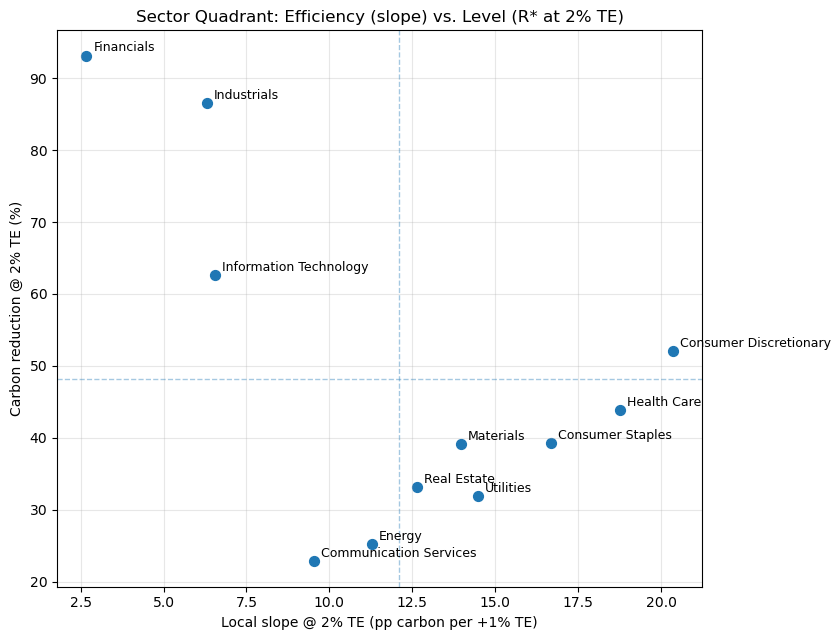

In [11]:
# --- Quadrant plot: local slope at 2% TE vs. carbon reduction level at 2% TE ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_TE_BPS = 200    # 2% TE
K_NEIGHBORS    = 7     # use up to 7 closest TE points for the local fit (min 3)

def _local_slope_at_target(te_bps, red_pct, target_bps=200, k=7):
    """
    te_bps: array-like of TE in basis points (e.g., [10, 20, ..., 500])
    red_pct: array-like of carbon reduction in percent (e.g., [12.3, 13.1, ...])
    Returns (slope_pp_per_pctTE, Rstar_pct) where:
      slope units = percentage-point carbon per +1% TE  (pp / %TE)
      Rstar_pct   = carbon reduction (%) at target TE (via local linear fit)
    """
    te_bps = np.asarray(te_bps, float)
    red_pct = np.asarray(red_pct, float)

    # guard: need at least 3 points
    if len(te_bps) < 3:
        return np.nan, np.nan

    # choose k nearest points to target_bps
    order = np.argsort(np.abs(te_bps - target_bps))
    idx = order[:max(3, min(k, len(te_bps)))]
    X_te_pct = te_bps[idx] / 100.0  # convert bps -> % TE
    y = red_pct[idx]

    # robust linear fit y = a + b * TE(%)
    X = np.c_[np.ones(len(idx)), X_te_pct]
    a, b = np.linalg.lstsq(X, y, rcond=None)[0]
    Rstar = a + b * (target_bps / 100.0)
    slope = b
    return float(slope), float(Rstar)

# Build metrics table from your sector_weights dict
rows = []
for sector_name, metrics in optimal_portfolios_all_te.items():
    te_bps = np.asarray(metrics['tracking_errors'], float)    # bps
    red_pct = np.asarray(metrics['carbon_reductions'], float) # %
    print(te_bps)
    print(red_pct)
    # Deduplicate any accidental duplicates (optional but helpful)
    df_tmp = pd.DataFrame({'te_bps': te_bps, 'red_pct': red_pct}) \
               .sort_values('te_bps') \
               .drop_duplicates(subset='te_bps', keep='last')

    slope, Rstar = _local_slope_at_target(
        df_tmp['te_bps'].values,
        df_tmp['red_pct'].values,
        target_bps=TARGET_TE_BPS,
        k=K_NEIGHBORS
    )
    rows.append({
        'Sector': sector_name,
        'Slope_at_2pct': slope,         # pp carbon per +1% TE
        'Rstar_at_2pct': Rstar          # % carbon reduction at 2% TE
    })

quad_df = pd.DataFrame(rows).sort_values('Sector')
print(quad_df.round(3))

# --- Quadrant scatter ---
fig, ax = plt.subplots(figsize=(8.5, 6.5))

x = quad_df['Slope_at_2pct'].values
y = quad_df['Rstar_at_2pct'].values
labels = quad_df['Sector'].values

ax.scatter(x, y, s=50)

# label points
for xi, yi, lab in zip(x, y, labels):
    if np.isfinite(xi) and np.isfinite(yi):
        ax.annotate(lab, (xi, yi), xytext=(5, 3), textcoords='offset points', fontsize=9)

# reference lines: medians (use np.nanmedian to ignore NaNs)
vx = float(np.nanmean(x))
hy = float(np.nanmean(y))
ax.axvline(vx, linestyle='--', linewidth=1, alpha=0.4)
ax.axhline(hy, linestyle='--', linewidth=1, alpha=0.4)

ax.set_xlabel('Local slope @ 2% TE (pp carbon per +1% TE)')
ax.set_ylabel('Carbon reduction @ 2% TE (%)')
ax.set_title('Sector Quadrant: Efficiency (slope) vs. Level (R* at 2% TE)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# --- knobs ---
eps = 0.02
delta_R  = 1e-3
delta_TE = 1e-8
K_dirs   = 500
NO_IMPROVE_PATIENCE = 40
ZERO_TOL = 1e-10

ECOS_OPTS = dict(abstol=1e-6, reltol=1e-6, feastol=1e-6, verbose=False)
SCS_OPTS  = dict(eps=5e-4, max_iters=5000, verbose=False, acceleration_lookback=20)
USE_SCS_FALLBACK = True

pickle_file = "Data/out-of-sample/sector_bands_1221.pkl"
excel_file  = "Data/out-of-sample/l2_bandwith_turnover_1221.xlsx"

# --- utilities ---
def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg, lw.shrinkage_

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

def process_sector(sector_name, info, data, log_returns_all):
    w_bench = info["w_bench"].astype(float).ravel()
    w_opt   = info["w_opt"].astype(float).ravel()
    stock_labels = list(info["stock_labels"])

    # covariance for this sector
    R_clean = log_returns_all[sector_name].drop(columns=['Date']).dropna()
    Sigma_sector, _ = sigma_reg_fn(R_clean)
    Sigma_sector = nearest_psd(Sigma_sector)

    # carbon vector
    c_vec = data.loc[data['GICS Sector'] == sector_name, ['Carbon Intensity']].values.flatten().astype(float)

    # baseline / optimal reduction
    c_b   = float(w_bench @ c_vec)
    c_opt = float(w_opt   @ c_vec)
    R_star = (c_b - c_opt) / c_b

    # TE cap (2% annual)
    te_annual = 0.02
    te_var_monthly_cap = (te_annual / np.sqrt(12))**2

    N = len(w_bench)

    # -------------------------------
    # A) ε-bands
    # -------------------------------
    def eps_constraints(w):
        return [
            cp.quad_form(w - w_bench, cp.psd_wrap(Sigma_sector)) <= te_var_monthly_cap,
            cp.sum(w) == 1,
            w >= 0,
            (c_b - c_vec @ w) / c_b >= (1 - eps) * R_star
        ]

    bands = []
    for i, name in enumerate(stock_labels):
        # Max w_i
        w = cp.Variable(N)
        prob_max = cp.Problem(cp.Maximize(w[i]), eps_constraints(w))
        prob_max.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_max.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_max.solve(solver=cp.SCS, **SCS_OPTS)
        w_max = w.value[i] if w.value is not None else np.nan

        # Min w_i
        w = cp.Variable(N)
        prob_min = cp.Problem(cp.Minimize(w[i]), eps_constraints(w))
        prob_min.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_min.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_min.solve(solver=cp.SCS, **SCS_OPTS)
        w_min = w.value[i] if w.value is not None else np.nan

        # hygiene
        if (not np.isfinite(w_min)) or (w_min < ZERO_TOL): w_min = 0.0
        if (not np.isfinite(w_max)) or (w_max < ZERO_TOL): w_max = 0.0
        w_min = float(min(max(w_min, 0.0), 1.0))
        w_max = float(min(max(w_max, 0.0), 1.0))

        bands.append([name, w_min, w_max, w_max - w_min])

    bands_df = pd.DataFrame(bands, columns=["symbol", "w_min", "w_max", "bandwidth"]).sort_values("bandwidth", ascending=False)

    # quick ε-band stats
    avg_bw = float(bands_df["bandwidth"].mean())
    med_bw = float(bands_df["bandwidth"].median())
    max_bw = float(bands_df["bandwidth"].max())
    pct_wmin_zero = float((bands_df["w_min"] <= ZERO_TOL).mean()) * 100.0

    # -------------------------------
    # B) L2 lower bound
    # -------------------------------
    w = cp.Variable(N)
    v = cp.Parameter(N)

    constraints_same_obj = [
        cp.quad_form(w - w_bench, cp.psd_wrap(Sigma_sector)) <= te_var_monthly_cap + delta_TE,
        cp.sum(w) == 1,
        w >= 0,
        ((c_b - c_vec @ w) / c_b) >= R_star - delta_R,
        ((c_b - c_vec @ w) / c_b) <= R_star + delta_R
    ]
    prob_dir = cp.Problem(cp.Maximize(v @ w), constraints_same_obj)

    rng = np.random.default_rng(42)
    best_lb = 0.0
    stale = 0

    for it in range(K_dirs):
        vv = rng.standard_normal(N)
        nrm = np.linalg.norm(vv)
        if nrm == 0:
            continue
        vv /= nrm

        # max v^T w
        v.value = vv
        prob_dir.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_dir.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_dir.solve(solver=cp.SCS, **SCS_OPTS)
        cand1 = abs(float(vv @ (w.value - w_opt))) if (w.value is not None) else 0.0

        # max (-v)^T w
        v.value = -vv
        prob_dir.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_dir.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_dir.solve(solver=cp.SCS, **SCS_OPTS)
        cand2 = abs(float((-vv) @ (w.value - w_opt))) if (w.value is not None) else 0.0

        new_best = max(best_lb, cand1, cand2)
        if new_best > best_lb + 1e-6:
            best_lb = new_best
            stale = 0
        else:
            stale += 1
            if stale >= NO_IMPROVE_PATIENCE:
                break

    l2_lower_bound = best_lb
    l1_turnover_upper = float(np.sqrt(N) * l2_lower_bound)

    # extra stats
    hhi_b = float(np.sum(w_bench**2))
    hhi_o = float(np.sum(w_opt**2))
    top3 = bands_df.sort_values("bandwidth", ascending=False).head(3)[["symbol","bandwidth"]]
    top3_list = [f"{r.symbol} ({r.bandwidth:.2%})" for r in top3.itertuples(index=False)]

    # -------------------------------
    # Row: pretty + raw fields
    # -------------------------------
    summary_row = {
        "Sector": sector_name,
        "Names (N)": N,
        "TE cap": "2.0%",
        "Tracking Error (bps)": f"{info['tracking_error_at_2pct']:.1f}",
        "Carbon reduction R*": f"{R_star:.1%}",
        "Carbon saved (abs)": f"{c_b - c_opt:.2f}",
        "HHI (bench → opt)": f"{hhi_b:.3f} → {hhi_o:.3f}",
        "Effective N (bench → opt)": f"{1/hhi_b:.1f} → {1/hhi_o:.1f}",
        "Support size (bench → opt)": f"{(w_bench>1e-4).sum()} → {(w_opt>1e-4).sum()}",
        "Avg / Median / Max ε-band": f"{avg_bw:.2%} / {med_bw:.2%} / {max_bw:.2%}",
        "90th pct ε-band": f"{bands_df['bandwidth'].quantile(0.9):.2%}",
        "% names at w_min=0": f"{pct_wmin_zero:.1f}%",
        "L2 lower bound (same obj)": f"{l2_lower_bound:.3f}",
        "Turnover UB (√N * L2)": f"{np.sqrt(N)*l2_lower_bound:.3f}",
        "Top flexible names": "; ".join(top3_list),
        "Most pinned name": bands_df.loc[bands_df["bandwidth"].idxmin(), "symbol"],

        # --- raw numeric fields for sorting ---
        "L2_lower_bound_same_obj": l2_lower_bound,
        "Avg_bandwidth": avg_bw,
        "Median_bandwidth": med_bw,
        "Max_bandwidth": max_bw,
        "Pct_wmin_zero": pct_wmin_zero,
    }

    return sector_name, bands_df, summary_row


# --- main driver ---
if os.path.exists(pickle_file) and os.path.exists(excel_file):
    print("✅ Using cached results, skipping recomputation.")
    with open(pickle_file, "rb") as f:
        sector_bands = pickle.load(f)
    sector_flexibility = pd.read_excel(excel_file)
else:
    print("⚡ Running full optimisation (no cache found)...")

    data = pd.read_excel("Data/out-of-sample/dataset_comp_1221.xlsx")
    log_returns_all = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_1221.xlsx", sheet_name=None)

    results = Parallel(n_jobs=-1)(
        delayed(process_sector)(s, i, data, log_returns_all)
        for s, i in optimal_portfolios_shrink_2_TE.items()
    )

    sector_bands = {s: b for s, b, _ in results}
    summary_rows = [r for _, _, r in results]
    sector_flexibility = pd.DataFrame(summary_rows).sort_values(
        ["L2_lower_bound_same_obj", "Avg_bandwidth"],
        ascending=[False, False]
    )

    # save to cache
    sector_flexibility.to_excel(excel_file, index=False)
    with open(pickle_file, "wb") as f:
        pickle.dump(sector_bands, f)

print("\n=== Sector Flexibility Summary (TE=2%) ===")
print(sector_flexibility.round(4).to_string(index=False))

✅ Using cached results, skipping recomputation.

=== Sector Flexibility Summary (TE=2%) ===
                Sector  Names (N) TE cap  Tracking Error (bps) Carbon reduction R*  Carbon saved (abs) HHI (bench → opt) Effective N (bench → opt) Support size (bench → opt) Avg / Median / Max ε-band 90th pct ε-band % names at w_min=0  L2 lower bound (same obj)  Turnover UB (√N * L2)                      Top flexible names Most pinned name  L2_lower_bound_same_obj  Avg_bandwidth  Median_bandwidth  Max_bandwidth  Pct_wmin_zero
            Financials         75   2.0%                200.00               93.1%                0.16     0.035 → 0.038               28.3 → 26.7                    75 → 52    6.81% / 7.33% / 13.94%           9.58%              97.3%                       0.02                   0.14   JPM (13.94%); V (13.19%); MA (12.40%)              IVZ                     0.02           0.07              0.07           0.14          97.33
             Utilities         28   2.0%        

In [13]:


def plot_sector_emissions_bar(sector_name, data, optimal_portfolios_shrink_2_TE,
                              top_k=12):
    """
    Bar/Pareto of emissions contribution under BENCHMARK weights:
    contribution_i = weight_in_sector_i * CarbonIntensity_i
    """
    df = (data.loc[data["GICS Sector"]==sector_name,
                   ["SYMBOL","weight_in_sector","Carbon Intensity"]]
             .copy())
    df["emissions_contrib"] = df["weight_in_sector"].astype(float) * \
                              df["Carbon Intensity"].astype(float)
    df.sort_values("emissions_contrib", ascending=False, inplace=True)
    df_top = df.head(top_k).reset_index(drop=True)
    df_top["cum_share"] = df_top["emissions_contrib"].cumsum()/df_top["emissions_contrib"].sum()

    fig, ax1 = plt.subplots(figsize=(8,4.2))
    ax1.bar(df_top["SYMBOL"], df_top["emissions_contrib"])
    ax1.set_ylabel("Emission contribution (w × CI)")
    ax1.set_title(f"{sector_name} — Emissions coverage (top {top_k})")
    ax1.set_xticklabels(df_top["SYMBOL"], rotation=45, ha="right")

    # Pareto line (cumulative share)
    ax2 = ax1.twinx()
    ax2.plot(df_top["SYMBOL"], df_top["cum_share"], marker="o")
    ax2.set_ylabel("Cumulative share")
    ax2.set_ylim(0,1.05)
    ax2.axhline(0.8, ls="--")  # 80% line
    plt.tight_layout()
    plt.show()


In [14]:

# =========================
# Config
# =========================
TE_TARGET   = 0.02      # 2% TE point for slope / elasticity
TE_AUC_MAX  = 0.05      # integrate AUC up to 5% TE
TE_WIN_BPS  = 25        # +/- window (in bps) around TE_TARGET for finite-diff slope
PLOT_ORDER  = None      # or provide a list of sector names to control row order

# =========================
# Helpers
# =========================
def _prep_frontier(te_bps, cuts_pct):
    """Sort by TE, convert TE bps->fraction and cuts %->fraction, dedup on TE (keep max cut)."""
    te = np.asarray(te_bps, float) / 10000.0
    c  = np.asarray(cuts_pct, float) / 100.0
    m  = np.isfinite(te) & np.isfinite(c)
    te, c = te[m], c[m]
    order = np.argsort(te)
    te, c = te[order], c[order]
    # collapse duplicate TE by taking max cut
    if len(np.unique(te)) != len(te):
        uniq_te = np.unique(te)
        uniq_c  = [np.nanmax(c[te == t]) for t in uniq_te]
        te, c = uniq_te, np.array(uniq_c)
    return te, c

def _interp(te0, te_grid, c_grid):
    """Linear interpolate c(te0); clip outside range."""
    if te0 <= te_grid[0]:
        return float(c_grid[0])
    if te0 >= te_grid[-1]:
        return float(c_grid[-1])
    return float(np.interp(te0, te_grid, c_grid))

def _slope_at(te_grid, c_grid, te0, win_bps=25):
    """Finite-difference slope dc/dTE using a small symmetric window around te0."""
    if len(te_grid) < 2: return np.nan
    h = win_bps / 10000.0
    tl = max(te_grid[0], te0 - h)
    tr = min(te_grid[-1], te0 + h)
    if tr <= tl: return np.nan
    cl = _interp(tl, te_grid, c_grid)
    cr = _interp(tr, te_grid, c_grid)
    return (cr - cl) / (tr - tl)

def _elasticity_at(te_grid, c_grid, te0, win_bps=25):
    """Elasticity ≈ slope * (TE / c)."""
    c0 = _interp(te0, te_grid, c_grid)
    s  = _slope_at(te_grid, c_grid, te0, win_bps)
    if not np.isfinite(c0) or c0 <= 0 or not np.isfinite(s): return np.nan
    return s * (te0 / c0)

def _auc_to(te_grid, c_grid, te_max):
    """Trapezoid area under c(TE) from 0 to te_max."""
    xs = np.unique(np.clip(np.r_[0.0, te_grid, te_max], 0, te_max))
    ys = np.array([_interp(x, te_grid, c_grid) for x in xs])
    return float(np.trapz(ys, xs))

def _te_for_cut(te_grid, c_grid, cut_frac):
    """Smallest TE where c(TE) >= cut_frac (linear). Returns np.nan if unreachable."""
    if c_grid[0] >= cut_frac: return 0.0
    if c_grid[-1] <  cut_frac: return np.nan
    idx = np.searchsorted(c_grid, cut_frac, side="left")
    if idx == 0: return float(te_grid[0])
    x0, x1 = te_grid[idx-1], te_grid[idx]
    y0, y1 = c_grid[idx-1], c_grid[idx]
    if y1 == y0: return float(x1)
    t = (cut_frac - y0) / (y1 - y0)
    return float(x0 + t*(x1 - x0))

def _minmax(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.sum() <= 1: return np.full_like(x, np.nan)
    lo, hi = np.nanmin(x[m]), np.nanmax(x[m])
    if hi == lo: return np.zeros_like(x)
    out = (x - lo) / (hi - lo)
    out[~m] = np.nan
    return out

# =========================
# Build the metrics table
# =========================
def build_room_for_maneuver(sector_weights,
                            te_target=TE_TARGET,
                            te_auc_max=TE_AUC_MAX,
                            te_win_bps=TE_WIN_BPS,
                            sector_order=PLOT_ORDER):
    rows, skipped = [], []
    for sector, d in sector_weights.items():
        te_bps = d.get('tracking_errors', [])
        c_pct  = d.get('carbon_reductions', [])
        if len(te_bps) == 0 or len(c_pct) == 0:
            skipped.append(sector); continue

        te, c = _prep_frontier(te_bps, c_pct)
        if len(te) < 2:
            skipped.append(sector); continue

        slope2   = _slope_at(te, c, te_target, te_win_bps)
        elast2   = _elasticity_at(te, c, te_target, te_win_bps)
        auc5     = _auc_to(te, c, te_auc_max)
        max5     = _interp(te_auc_max, te, c)
        te50     = _te_for_cut(te, c, 0.50)

        rows.append(dict(
            Sector=sector,
            Slope_at_2pct=slope2,                # dc / dTE  at 2%
            Elasticity_at_2pct=elast2,           # (dc/c)/(dTE/TE) at 2%
            AUC_to_5pctTE=auc5,                  # ∫ c(TE) dTE, TE∈[0,5%]
            MaxCut_at_5pctTE=max5,               # c(5% TE)
            TE_for_50pctCut=te50                 # min TE s.t. c >= 50%
        ))

    df = pd.DataFrame(rows)
    if df.empty:
        return df, skipped

    # Normalizations (higher=better), invert TE_for_50pctCut
    df["norm_Slope_at_2pct"]      = _minmax(df["Slope_at_2pct"])
    df["norm_Elasticity_at_2pct"] = _minmax(df["Elasticity_at_2pct"])
    df["norm_AUC_to_5pctTE"]      = _minmax(df["AUC_to_5pctTE"])
    df["norm_MaxCut_at_5pctTE"]   = _minmax(df["MaxCut_at_5pctTE"])
    inv_te50                      = 1.0 - _minmax(df["TE_for_50pctCut"])
    df["norm_TE_for_50pctCut"]    = inv_te50

    norm_cols = [c for c in df.columns if c.startswith("norm_")]
    df["Composite_Score"] = np.nanmean(df[norm_cols].to_numpy(float), axis=1)

    # Optional ordering
    if sector_order:
        df["__ord__"] = pd.Categorical(df["Sector"], categories=sector_order, ordered=True)
        df = df.sort_values("__ord__").drop(columns="__ord__")
    else:
        df = df.sort_values("Sector")

    return df, skipped

def plot_cross_sector_heatmap(metrics_df):
    viz_cols   = ["norm_Slope_at_2pct", "norm_Elasticity_at_2pct",
                  "norm_AUC_to_5pctTE", "norm_MaxCut_at_5pctTE", "norm_TE_for_50pctCut"]
    viz_labels = ["Slope@2%", "Elasticity@2%", "AUC≤5%TE", "Max@5%TE", "Low TE@50%"]

    H = metrics_df[viz_cols].to_numpy(float)
    sectors = metrics_df["Sector"].tolist()

    fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(sectors))))
    im = ax.imshow(H, aspect="auto")
    ax.set_yticks(np.arange(len(sectors)))
    ax.set_yticklabels(sectors)
    ax.set_xticks(np.arange(len(viz_labels)))
    ax.set_xticklabels(viz_labels, rotation=45, ha="right")
    ax.set_title("Room for Maneuver — normalized metrics (darker = better)")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Normalized score")

    # annotate
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            val = H[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

def plot_composite_bar(metrics_df):
    order = np.argsort(-metrics_df["Composite_Score"].to_numpy(float))
    sectors = np.array(metrics_df["Sector"])[order]
    scores  = metrics_df["Composite_Score"].to_numpy(float)[order]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(sectors, scores)
    ax.set_ylabel("Composite score (0–1)")
    ax.set_title("Room for Maneuver — Composite Ranking")
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# =========================
# Run it
# =========================
metrics_df, skipped = build_room_for_maneuver(optimal_portfolios_all_te,
                                              te_target=TE_TARGET,
                                              te_auc_max=TE_AUC_MAX,
                                              te_win_bps=TE_WIN_BPS,
                                              sector_order=PLOT_ORDER)

print("\n=== Room for Maneuver — per sector (raw & composite) ===")
display_cols = ["Sector","Slope_at_2pct","Elasticity_at_2pct","AUC_to_5pctTE","MaxCut_at_5pctTE","TE_for_50pctCut","Composite_Score"]
print(metrics_df[display_cols].round(3).to_string(index=False))

if skipped:
    print("\n(Frontier missing/too short for: " + ", ".join(skipped) + ")")

# # Visualizations
# plot_cross_sector_heatmap(metrics_df)
# plot_composite_bar(metrics_df)



=== Room for Maneuver — per sector (raw & composite) ===
                Sector  Slope_at_2pct  Elasticity_at_2pct  AUC_to_5pctTE  MaxCut_at_5pctTE  TE_for_50pctCut  Composite_Score
Communication Services           9.57                0.84           0.01              0.43              NaN             0.33
Consumer Discretionary          20.30                0.78           0.03              0.75             0.02             0.68
      Consumer Staples          16.71                0.85           0.02              0.74             0.03             0.60
                Energy          11.32                0.90           0.01              0.54             0.04             0.35
            Financials           2.64                0.06           0.05              0.97             0.00             0.60
           Health Care          18.77                0.86           0.03              0.82             0.02             0.68
           Industrials           6.51                0.15          

# Weight Perturbation Sensitivity – Before and After
Answering to the question: "Which sectors deliver robust solutions under changing input assumptions?"

In [15]:
ordered_sectors = [
    "Industrials",
    "Financials",
    "Consumer Discretionary",
    "Health Care",
    "Information Technology",
    "Consumer Staples",
    "Energy",
    "Materials",
    "Real Estate",
    "Utilities",
    "Communication Services"
]

Skipped existing: figures/correlations/1221/Consumer Discretionary_corr_raw.png
Skipped existing: figures/correlations/1221/Consumer Discretionary_corr_reg.png
Skipped existing: figures/correlations/1221/Health Care_corr_raw.png
Skipped existing: figures/correlations/1221/Health Care_corr_reg.png
Skipped existing: figures/correlations/1221/Utilities_corr_raw.png
Skipped existing: figures/correlations/1221/Utilities_corr_reg.png
Skipped existing: figures/correlations/1221/Information Technology_corr_raw.png
Skipped existing: figures/correlations/1221/Information Technology_corr_reg.png
Skipped existing: figures/correlations/1221/Real Estate_corr_raw.png
Skipped existing: figures/correlations/1221/Real Estate_corr_reg.png
Skipped existing: figures/correlations/1221/Materials_corr_raw.png
Skipped existing: figures/correlations/1221/Materials_corr_reg.png
Skipped existing: figures/correlations/1221/Industrials_corr_raw.png
Skipped existing: figures/correlations/1221/Industrials_corr_reg.pn

/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Skipped existing: figures/correlations/1221/Energy_corr_raw.png
Skipped existing: figures/correlations/1221/Energy_corr_reg.png
Skipped existing: figures/correlations/1221/Communication Services_corr_raw.png
Skipped existing: figures/correlations/1221/Communication Services_corr_reg.png
Skipped existing: figures/correlations/1221/Consumer Staples_corr_raw.png
Skipped existing: figures/correlations/1221/Consumer Staples_corr_reg.png


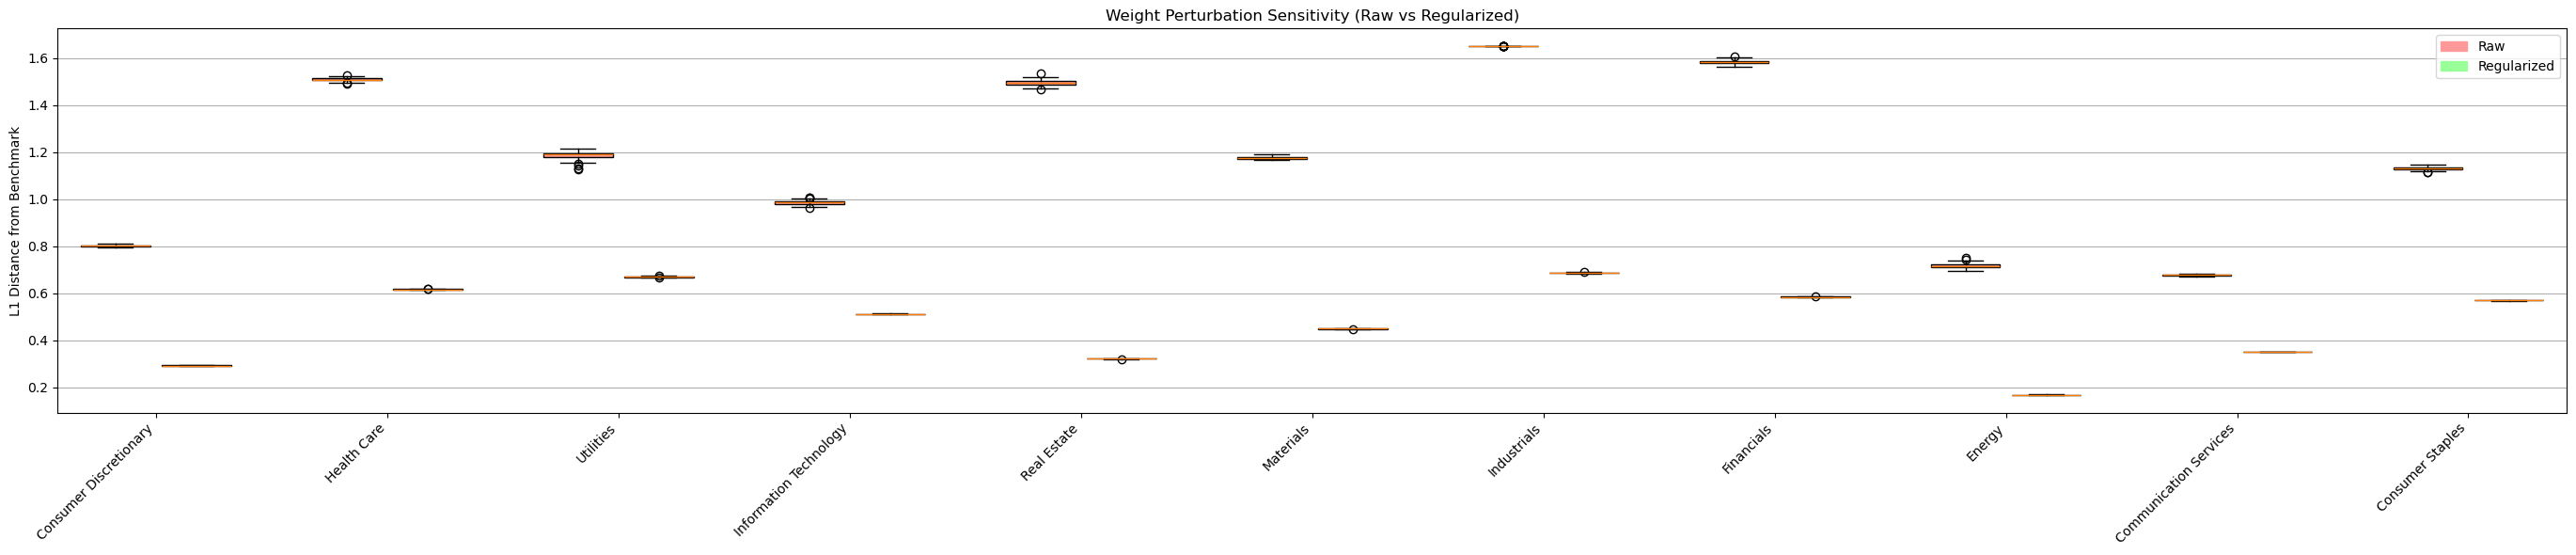

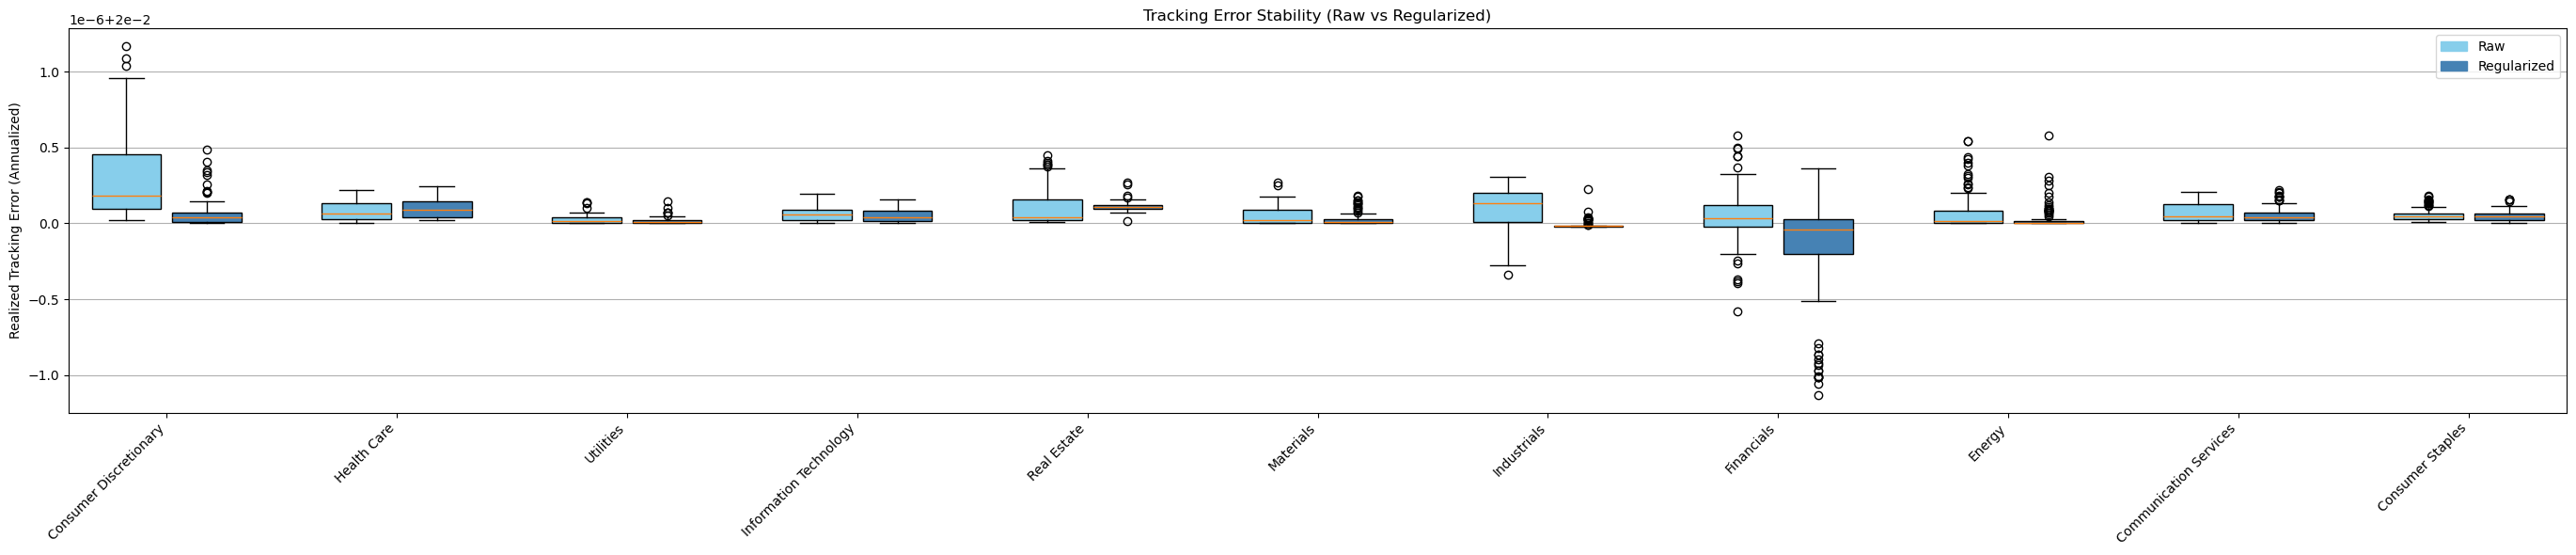

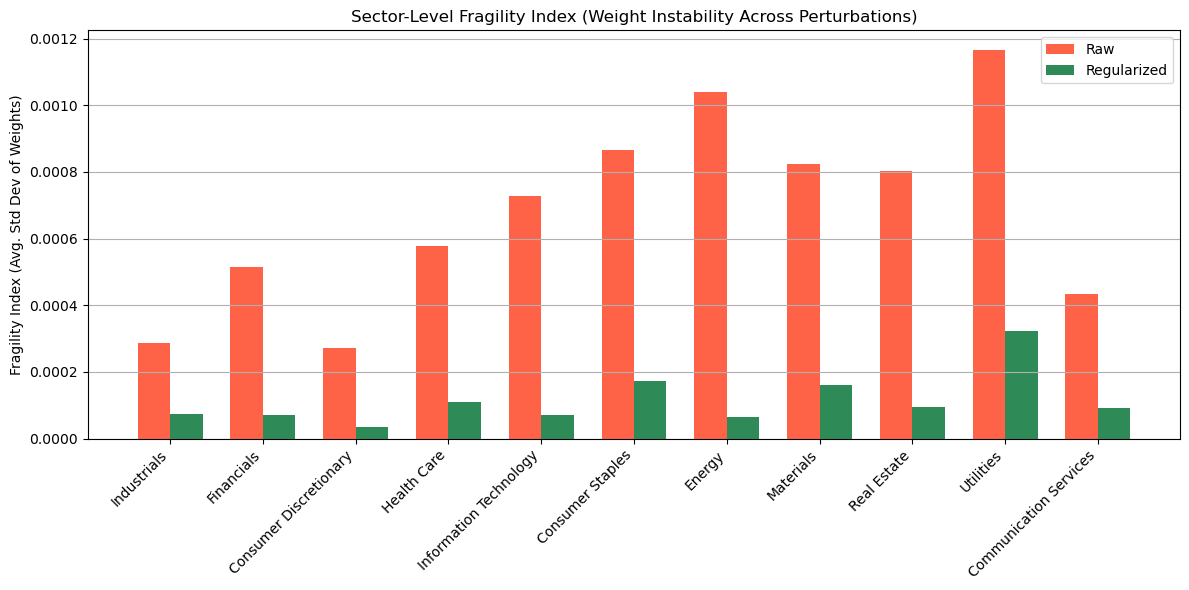

In [16]:
def sigma_reg_fn(R_clean):
    # Apply Ledoit-Wolf shrinkage
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_

    # --- λI regularization ---
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg

def compute_perturbed_weights(
    R_clean,
    w_bench,
    c_vec,
    Sigma_fn,
    te_cap=0.03,
    n_trials=100,
    noise_std=0.01
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    weights = []
    tracking_errors = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)
        R_perturbed = R_clean + R_clean.multiply(noise)
        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            # compute realized TE
            diff = w.value - w_bench
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)


data = pd.read_excel("Data/out-of-sample/dataset_comp_1221.xlsx")

import os

output_dir = "figures/correlations/1221/"
os.makedirs(output_dir, exist_ok=True)

for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_1221.xlsx", sheet_name=sector_name)
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()

    # --- File paths for caching ---
    raw_path = os.path.join(output_dir, f"{sector_name}_corr_raw.png")
    reg_path = os.path.join(output_dir, f"{sector_name}_corr_reg.png")

    # --- RAW Correlation Histogram ---
    if not os.path.exists(raw_path):
        corr_raw = np.corrcoef(R_clean.T)
        off_diag_raw = corr_raw[~np.eye(corr_raw.shape[0], dtype=bool)]

        plt.figure(figsize=(5, 3))
        plt.hist(off_diag_raw, bins=40, color='lightcoral', edgecolor='black')
        plt.xlim(-0.5, 1)
        plt.title(f"{sector_name} – Raw Correlation Values")
        plt.xlabel("Correlation")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.grid(True)
        plt.savefig(raw_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved: {raw_path}")
    else:
        print(f"Skipped existing: {raw_path}")

    # --- REGULARIZED Correlation Histogram ---
    if not os.path.exists(reg_path):
        Sigma_reg = sigma_reg_fn(R_clean)
        stds = np.sqrt(np.diag(Sigma_reg))
        corr_reg = Sigma_reg / np.outer(stds, stds)
        np.fill_diagonal(corr_reg, np.nan)
        off_diag_reg = corr_reg[~np.isnan(corr_reg)]

        plt.figure(figsize=(5, 3))
        plt.hist(off_diag_reg, bins=40, color='mediumseagreen', edgecolor='black')
        plt.xlim(-0.5, 1)
        plt.title(f"{sector_name} – Regularized Correlation Values")
        plt.xlabel("Correlation")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.grid(True)
        plt.savefig(reg_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved: {reg_path}")
    else:
        print(f"Skipped existing: {reg_path}")


    sector = data.loc[data['GICS Sector'] == sector_name]

    w_b_sector = sector[['weight_in_sector']]
    w_bench = w_b_sector.values.flatten()
    c_sector = sector[['Carbon Intensity']]
    c_vec = c_sector.values.flatten()
    
    w_pert_raw, te_pert_raw = compute_perturbed_weights(R_clean, w_bench, c_vec, sigma_raw_fn, te_cap=0.02)
    w_pert_reg, te_pert_reg = compute_perturbed_weights(R_clean, w_bench, c_vec, sigma_reg_fn, te_cap=0.02)

    # Store
    optimal_portfolios_all_te[sector_name]["te_raw"] = te_pert_raw[~np.isnan(te_pert_raw)]
    optimal_portfolios_all_te[sector_name]["te_reg"] = te_pert_reg[~np.isnan(te_pert_reg)]

    # Compute standard deviation across perturbations (axis=0 → across trials)
    frag_raw = np.nanstd(w_pert_raw, axis=0).mean()
    frag_reg = np.nanstd(w_pert_reg, axis=0).mean()

    optimal_portfolios_all_te[sector_name]["frag_raw"] = frag_raw
    optimal_portfolios_all_te[sector_name]["frag_reg"] = frag_reg

    # L1 distances from baseline
    baseline_w = w_bench
    l1_raw = [np.sum(np.abs(w - baseline_w)) for w in w_pert_raw if not np.isnan(w).any()]
    l1_reg = [np.sum(np.abs(w - baseline_w)) for w in w_pert_reg if not np.isnan(w).any()]

    optimal_portfolios_all_te[sector_name]["l1_raw"] = l1_raw
    optimal_portfolios_all_te[sector_name]["l1_reg"] = l1_reg

    sectors = list(optimal_portfolios_all_te.keys())
num_sectors = len(sectors)

fig, ax = plt.subplots(figsize=(2.5 * num_sectors, 6))

# Prepare data and positions
all_data = []
positions = []
labels = []
colors = []

for i, sector in enumerate(sectors):
    raw = optimal_portfolios_all_te[sector]['l1_raw']
    reg = optimal_portfolios_all_te[sector]['l1_reg']
    
    all_data.extend([raw, reg])
    positions.extend([2 * i, 2 * i + 0.7])
    labels.extend([f'{sector}\nRaw', 'Reg'])
    colors.extend(['#ff9999', '#99ff99'])  # light red, light green

# Plot boxplots
box = ax.boxplot(all_data, positions=positions, patch_artist=True, widths=0.6)

# Apply custom colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis
ax.set_xticks([2 * i + 0.35 for i in range(num_sectors)])
ax.set_xticklabels(sectors, rotation=45, ha='right')

# Labels and styling
ax.set_ylabel("L1 Distance from Benchmark")
ax.set_title("Weight Perturbation Sensitivity (Raw vs Regularized)")
ax.grid(True, axis='y')

# Legend manually
legend_patches = [Patch(color='#ff9999', label='Raw'), Patch(color='#99ff99', label='Regularized')]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(2.5 * num_sectors, 6))
all_te_data = []
te_positions = []
te_colors = []
te_labels = []

for i, sector in enumerate(sectors):
    raw = optimal_portfolios_all_te[sector]['te_raw']
    reg = optimal_portfolios_all_te[sector]['te_reg']

    all_te_data.extend([raw, reg])
    te_positions.extend([2 * i, 2 * i + 0.7])
    te_labels.extend([f'{sector}\nRaw', 'Reg'])
    te_colors.extend(['#87CEEB', '#4682B4'])  # blue shades

box = ax.boxplot(all_te_data, positions=te_positions, patch_artist=True, widths=0.6)
for patch, color in zip(box['boxes'], te_colors):
    patch.set_facecolor(color)

ax.set_xticks([2 * i + 0.35 for i in range(num_sectors)])
ax.set_xticklabels(sectors, rotation=45, ha='right')
ax.set_ylabel("Realized Tracking Error (Annualized)")
ax.set_title("Tracking Error Stability (Raw vs Regularized)")
ax.grid(True, axis='y')

legend_patches = [Patch(color='#87CEEB', label='Raw'), Patch(color='#4682B4', label='Regularized')]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()

frag_raw_all = []
frag_reg_all = []
sectors = []

for sector_name in ordered_sectors:
    if sector_name in optimal_portfolios_all_te:
        if "frag_raw" in optimal_portfolios_all_te[sector_name] and "frag_reg" in optimal_portfolios_all_te[sector_name]:
            frag_raw_all.append(optimal_portfolios_all_te[sector_name]["frag_raw"])
            frag_reg_all.append(optimal_portfolios_all_te[sector_name]["frag_reg"])
            sectors.append(sector_name)

x = np.arange(len(sectors))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, frag_raw_all, width, label='Raw', color='tomato')
plt.bar(x + width/2, frag_reg_all, width, label='Regularized', color='seagreen')
plt.xticks(x, sectors, rotation=45, ha='right')
plt.ylabel("Fragility Index (Avg. Std Dev of Weights)")
plt.title("Sector-Level Fragility Index (Weight Instability Across Perturbations)")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()



In [17]:

# === UTILITIES ===

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    return Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])

def simulate_parametric_noise(mu, Sigma, T, n_trials):
    return [np.random.multivariate_normal(mu, Sigma, T) for _ in range(n_trials)]

def bootstrap_returns(R_clean_np, n_trials):
    T = R_clean_np.shape[0]
    return [R_clean_np[np.random.choice(T, T, replace=True)] for _ in range(n_trials)]

def compute_perturbed_weights_from_samples(R_samples, w_bench, c_vec, Sigma_fn, te_cap=0.03):
    weights, tracking_errors = [], []
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    N = len(w_bench)

    for R_perturbed in R_samples:
        Sigma = Sigma_fn(pd.DataFrame(R_perturbed))
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_bench
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)

def compute_perturbed_weights(
    R_clean,
    w_bench,
    c_vec,
    Sigma_fn,
    te_cap=0.03,
    n_trials=100,
    noise_std=0.01,
    noise_type="multiplicative"  # or "additive"
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    weights = []
    tracking_errors = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)

        if noise_type == "multiplicative":
            R_perturbed = R_clean + R_clean.multiply(noise)
        elif noise_type == "additive":
            R_perturbed = R_clean + noise
        else:
            raise ValueError("noise_type must be 'multiplicative' or 'additive'")

        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_bench
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)


def compute_hhi(weights):
    return np.sum(np.square(weights))

def check_total_variability(R_clean, sector_name):
    stds = R_clean.std(axis=0)
    avg_std = np.mean(stds)
    print(f"{sector_name}: Avg Std Dev = {avg_std:.4f}")

In [18]:
import os
import pickle
import pandas as pd
import numpy as np

# === Config ===
data = pd.read_excel("Data/out-of-sample/dataset_comp_1221.xlsx")
cache_dir = "cache/1221/perturbation_weights/"
os.makedirs(cache_dir, exist_ok=True)

n_trials = 100
sector_weights = {}

# Optional: set to True to overwrite cache
force_recompute = False  

for sector_name in data['GICS Sector'].unique():
    cache_path = os.path.join(cache_dir, f"{sector_name}.pkl")

    # --- Load from cache if available ---
    if not force_recompute and os.path.exists(cache_path):
        try:
            with open(cache_path, "rb") as f:
                cached_data = pickle.load(f)
            # optional sanity check
            if isinstance(cached_data, dict) and len(cached_data) > 0:
                print(f"⚡ Skipping {sector_name} (cached)")
                sector_weights[sector_name] = cached_data
                continue
            else:
                print(f"⚠️ Cache for {sector_name} is empty or invalid — recomputing...")
        except Exception as e:
            print(f"⚠️ Failed to load cache for {sector_name}: {e}. Recomputing...")

    # --- Compute if not cached ---
    print(f"🔄 Processing {sector_name}...")

    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_1221.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    R_np = R_clean.values
    mu_hat = R_np.mean(axis=0)
    Sigma_hat = np.cov(R_np, rowvar=False)
    T = R_np.shape[0]

    sector = data[data['GICS Sector'] == sector_name]
    w_bench = sector['weight_in_sector'].values
    c_vec = sector['Carbon Intensity'].values

    # --- Simulations ---
    param_samples = simulate_parametric_noise(mu_hat, Sigma_hat, T, n_trials)
    boot_samples = bootstrap_returns(R_np, n_trials)

    # --- Optimizations (Raw vs Regularized) ---
    w_param_raw, te_param_raw = compute_perturbed_weights_from_samples(param_samples, w_bench, c_vec, sigma_raw_fn)
    w_param_reg, te_param_reg = compute_perturbed_weights_from_samples(param_samples, w_bench, c_vec, sigma_reg_fn)
    w_boot_raw, te_boot_raw = compute_perturbed_weights_from_samples(boot_samples, w_bench, c_vec, sigma_raw_fn)
    w_boot_reg, te_boot_reg = compute_perturbed_weights_from_samples(boot_samples, w_bench, c_vec, sigma_reg_fn)

    w_mult_raw, te_mult_raw = compute_perturbed_weights(R_clean, w_bench, c_vec, sigma_raw_fn, noise_type="multiplicative", noise_std=0.3)
    w_mult_reg, te_mult_reg = compute_perturbed_weights(R_clean, w_bench, c_vec, sigma_reg_fn, noise_type="multiplicative", noise_std=0.3)
    w_add_raw, te_add_raw = compute_perturbed_weights(R_clean, w_bench, c_vec, sigma_raw_fn, noise_type="additive")
    w_add_reg, te_add_reg = compute_perturbed_weights(R_clean, w_bench, c_vec, sigma_reg_fn, noise_type="additive")

    # --- Condition numbers ---
    cond_raw = np.linalg.cond(sigma_raw_fn(R_clean))
    cond_reg = np.linalg.cond(sigma_reg_fn(R_clean))

    # --- Fragility metrics ---
    frag_param_raw = np.nanstd(w_param_raw, axis=0).mean()
    frag_param_reg = np.nanstd(w_param_reg, axis=0).mean()
    frag_boot_raw = np.nanstd(w_boot_raw, axis=0).mean()
    frag_boot_reg = np.nanstd(w_boot_reg, axis=0).mean()
    frag_mult_raw = np.nanstd(w_mult_raw, axis=0).mean()
    frag_mult_reg = np.nanstd(w_mult_reg, axis=0).mean()
    frag_add_raw = np.nanstd(w_add_raw, axis=0).mean()
    frag_add_reg = np.nanstd(w_add_reg, axis=0).mean()

    frag_ratio_param = frag_param_raw / frag_param_reg if frag_param_reg > 0 else np.nan
    frag_ratio_boot = frag_boot_raw / frag_boot_reg if frag_boot_reg > 0 else np.nan
    frag_ratio_mult = frag_mult_raw / frag_mult_reg if frag_mult_reg > 0 else np.nan
    frag_ratio_add = frag_add_raw / frag_add_reg if frag_add_reg > 0 else np.nan

    # --- L1 distances ---
    def safe_l1(ws): 
        return [np.sum(np.abs(w - w_bench)) for w in ws if not np.isnan(w).any()]

    l1_param_raw, l1_param_reg = safe_l1(w_param_raw), safe_l1(w_param_reg)
    l1_boot_raw, l1_boot_reg = safe_l1(w_boot_raw), safe_l1(w_boot_reg)
    l1_mult_raw, l1_mult_reg = safe_l1(w_mult_raw), safe_l1(w_mult_reg)
    l1_add_raw, l1_add_reg = safe_l1(w_add_raw), safe_l1(w_add_reg)

    # --- HHI ---
    def compute_hhi(w): return np.sum(np.square(w))
    hhi_benchmark = compute_hhi(w_bench)

    sector_data = {
        # Fragility
        "frag_param_raw": frag_param_raw, "frag_param_reg": frag_param_reg,
        "frag_boot_raw": frag_boot_raw, "frag_boot_reg": frag_boot_reg,
        "frag_mult_raw": frag_mult_raw, "frag_mult_reg": frag_mult_reg,
        "frag_add_raw": frag_add_raw, "frag_add_reg": frag_add_reg,
        # Fragility ratios
        "frag_ratio_param": frag_ratio_param, "frag_ratio_boot": frag_ratio_boot,
        "frag_ratio_mult": frag_ratio_mult, "frag_ratio_add": frag_ratio_add,
        # L1 distances
        "l1_param_raw": l1_param_raw, "l1_param_reg": l1_param_reg,
        "l1_boot_raw": l1_boot_raw, "l1_boot_reg": l1_boot_reg,
        "l1_mult_raw": l1_mult_raw, "l1_mult_reg": l1_mult_reg,
        "l1_add_raw": l1_add_raw, "l1_add_reg": l1_add_reg,
        # Tracking error
        "te_param_raw": te_param_raw, "te_param_reg": te_param_reg,
        "te_boot_raw": te_boot_raw, "te_boot_reg": te_boot_reg,
        "te_mult_raw": te_mult_raw, "te_mult_reg": te_mult_reg,
        "te_add_raw": te_add_raw, "te_add_reg": te_add_reg,
        # HHI
        "hhi_benchmark": hhi_benchmark,
        "hhi_param_raw": np.nanmean([compute_hhi(w) for w in w_param_raw if not np.isnan(w).any()]),
        "hhi_param_reg": np.nanmean([compute_hhi(w) for w in w_param_reg if not np.isnan(w).any()]),
        "hhi_boot_raw": np.nanmean([compute_hhi(w) for w in w_boot_raw if not np.isnan(w).any()]),
        "hhi_boot_reg": np.nanmean([compute_hhi(w) for w in w_boot_reg if not np.isnan(w).any()]),
        "hhi_mult_raw": np.nanmean([compute_hhi(w) for w in w_mult_raw if not np.isnan(w).any()]),
        "hhi_mult_reg": np.nanmean([compute_hhi(w) for w in w_mult_reg if not np.isnan(w).any()]),
        "hhi_add_raw": np.nanmean([compute_hhi(w) for w in w_add_raw if not np.isnan(w).any()]),
        "hhi_add_reg": np.nanmean([compute_hhi(w) for w in w_add_reg if not np.isnan(w).any()]),
        # Condition numbers
        "cond_raw": cond_raw, "cond_reg": cond_reg
    }

    # --- Cache results ---
    with open(cache_path, "wb") as f:
        pickle.dump(sector_data, f)

    sector_weights[sector_name] = sector_data
    print(f"✅ Saved results for {sector_name} → {cache_path}")

🔄 Processing Consumer Discretionary...
✅ Saved results for Consumer Discretionary → cache/1221/perturbation_weights/Consumer Discretionary.pkl
🔄 Processing Health Care...
✅ Saved results for Health Care → cache/1221/perturbation_weights/Health Care.pkl
🔄 Processing Utilities...
✅ Saved results for Utilities → cache/1221/perturbation_weights/Utilities.pkl
🔄 Processing Information Technology...
✅ Saved results for Information Technology → cache/1221/perturbation_weights/Information Technology.pkl
🔄 Processing Real Estate...
✅ Saved results for Real Estate → cache/1221/perturbation_weights/Real Estate.pkl
🔄 Processing Materials...
✅ Saved results for Materials → cache/1221/perturbation_weights/Materials.pkl
🔄 Processing Industrials...
✅ Saved results for Industrials → cache/1221/perturbation_weights/Industrials.pkl
🔄 Processing Financials...


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


✅ Saved results for Financials → cache/1221/perturbation_weights/Financials.pkl
🔄 Processing Energy...
✅ Saved results for Energy → cache/1221/perturbation_weights/Energy.pkl
🔄 Processing Communication Services...
✅ Saved results for Communication Services → cache/1221/perturbation_weights/Communication Services.pkl
🔄 Processing Consumer Staples...
✅ Saved results for Consumer Staples → cache/1221/perturbation_weights/Consumer Staples.pkl


In [19]:

# ---------- helpers ----------
def l1_turnover_pct(w_from, w_to):
    """One-way turnover (% of portfolio) to go from w_from → w_to."""
    return 0.5 * float(np.abs(w_to - w_from).sum()) * 100.0

def cosine_similarity(a, b):
    a = np.asarray(a); b = np.asarray(b)
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

def realized_te_annual(w, w_b, Sigma):
    """Annualized TE in decimal (e.g., 0.02 == 2%)."""
    diff = (w - w_b)
    te_m = float(diff.T @ Sigma @ diff)
    te_a = np.sqrt(te_m) * np.sqrt(12.0)
    return te_a

def carbon_reduction_pct(w, w_b, c_vec):
    """% reduction relative to benchmark carbon; returns in percent units."""
    cb = float(np.dot(w_b, c_vec))
    co = float(np.dot(w,   c_vec))
    if cb == 0:
        return np.nan
    return (cb - co) / cb * 100.0

def nanpercentile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.percentile(x, q)) if x.size else np.nan

def sensitivity_kpis_from_trials(
    w_trials,             # (n_trials, N) weights from perturbations (optimized each trial)
    te_trials_annual,     # (n_trials,) TE in decimal for each trial (annualized)
    R_clean,              # baseline returns (DataFrame without Date)
    w_bench,              # benchmark weights (N,)
    c_vec,                # carbon intensity per name (N,)
    Sigma_fn,             # function R_clean -> Sigma
    te_cap=0.02,          # baseline TE cap (annual)
    w_opt0=None           # baseline optimized weights; if None, will solve
):
    """
    Returns a dict with the KPIs + the raw per-trial series (for plots).
    """
    # Baseline (with clean Sigma)
    w_opt0, te0, Rstar0, Sigma0 = baseline_diagnostics(R_clean, w_bench, c_vec, Sigma_fn, te_cap, w_opt0)

    # Per-trial measures vs baseline optimized portfolio
    turnovers = []
    cosines   = []
    carbon_losses_pp = []   # baseline reduction minus trial reduction (pp)
    te_drifts_bps    = []   # |TE_trial - TE_baseline| in bps

    for w_t, te_t in zip(w_trials, te_trials_annual):
        if w_t is None or not np.all(np.isfinite(w_t)) or (te_t is None) or not np.isfinite(te_t):
            turnovers.append(np.nan); cosines.append(np.nan)
            carbon_losses_pp.append(np.nan); te_drifts_bps.append(np.nan)
            continue

        # Turnover and Cosine vs baseline optimized
        turnovers.append(l1_turnover_pct(w_opt0, w_t))
        cosines.append(cosine_similarity(w_opt0, w_t))

        # Carbon reduction loss (pp): max(0, baseline_reduction - trial_reduction)
        Rstar_t = carbon_reduction_pct(w_t, w_bench, c_vec)   # in %
        carbon_losses_pp.append(max(0.0, Rstar0 - Rstar_t))

        # TE drift (bps) relative to baseline TE
        te_drifts_bps.append(abs(te_t - te0) * 10000.0)

    # Aggregate KPIs
    kpis = {
        "Median_Turnover_pct":        nanpercentile(turnovers, 50),
        "Median_Cosine":              nanpercentile(cosines, 50),
        "P95_CarbonLoss_pp":          nanpercentile(carbon_losses_pp, 95),
        "P95_TE_Drift_bps":           nanpercentile(te_drifts_bps, 95),
        # keep handy for plots/debug
        "series": {
            "turnover_pct": np.array(turnovers, dtype=float),
            "cosine":       np.array(cosines, dtype=float),
            "carbon_loss_pp": np.array(carbon_losses_pp, dtype=float),
            "te_drift_bps":   np.array(te_drifts_bps, dtype=float),
            "baseline": {
                "w_opt0": w_opt0,
                "te0_annual": te0,
                "Rstar0_pct": Rstar0
            }
        }
    }
    return kpis

# ---------- baseline (can reuse your precomputed dict) ----------
def baseline_diagnostics(R_clean, w_bench, c_vec, Sigma_fn, te_cap=0.02, w_opt=None):
    """
    Returns (w_opt0, te0_annual, Rstar0, Sigma0)
    - If w_opt is None, solves the baseline optimization; otherwise uses provided w_opt.
    """
    # Sigma at baseline (on clean returns)
    Sigma0 = Sigma_fn(R_clean)

    if w_opt is None:
        # Solve baseline optim (same as your optimize_sector but minimal)
        N = len(w_bench)
        w = cp.Variable(N)
        te_cap_var_monthly = (te_cap / np.sqrt(12))**2
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma0))
        obj = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        cons = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(obj, cons)
        prob.solve(solver=cp.ECOS, verbose=False)
        if prob.status not in ("optimal","optimal_inaccurate") or w.value is None:
            raise RuntimeError(f"Baseline optimization failed: {prob.status}")
        w_opt0 = w.value
    else:
        w_opt0 = np.asarray(w_opt, dtype=float)

    te0 = realized_te_annual(w_opt0, w_bench, Sigma0)              # decimal, e.g. 0.02
    Rstar0 = carbon_reduction_pct(w_opt0, w_bench, c_vec)          # percent
    return w_opt0, te0, Rstar0, Sigma0

In [20]:

# number of perturbations
n_trials = 100

sensitivity_results = {}

for sector_name in data['GICS Sector'].unique():
    print(f"[{sector_name}] computing sensitivity KPIs…")

    # Load returns for this sector
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_1221.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()

    # Benchmark weights + carbon intensity
    sector = data[data['GICS Sector'] == sector_name]
    w_bench = sector['weight_in_sector'].values
    c_vec   = sector['Carbon Intensity'].values

    # Baseline optimized weights (already precomputed in your dict)
    w_opt0 = optimal_portfolios_shrink_2_TE[sector_name]["w_opt"]

    # === Perturbations ===
    # Use multiplicative noise on returns + regularized covariance (recommended)
    w_trials, te_trials = compute_perturbed_weights(
        R_clean,
        w_bench,
        c_vec,
        sigma_reg_fn,
        te_cap=0.02,          # annual TE cap
        n_trials=n_trials,
        noise_std=0.3,
        noise_type="multiplicative"
    )

    # === Compute KPIs ===
    kpis = sensitivity_kpis_from_trials(
        w_trials=w_trials,
        te_trials_annual=te_trials,
        R_clean=R_clean,
        w_bench=w_bench,
        c_vec=c_vec,
        Sigma_fn=sigma_reg_fn,
        te_cap=0.02,
        w_opt0=w_opt0
    )

    sensitivity_results[sector_name] = {
        "Median_Turnover_pct": kpis["Median_Turnover_pct"],
        "Median_Cosine": kpis["Median_Cosine"],
        "P95_CarbonLoss_pp": kpis["P95_CarbonLoss_pp"],
        "P95_TE_Drift_bps": kpis["P95_TE_Drift_bps"],
    }

# Save results to pickle
with open("results/1221/sensitivity_kpis.pkl", "wb") as f:
    pickle.dump(sensitivity_results, f)

print("✅ All done. Saved sensitivity KPIs to sensitivity_kpis.pkl")


[Consumer Discretionary] computing sensitivity KPIs…
[Health Care] computing sensitivity KPIs…
[Utilities] computing sensitivity KPIs…
[Information Technology] computing sensitivity KPIs…
[Real Estate] computing sensitivity KPIs…
[Materials] computing sensitivity KPIs…
[Industrials] computing sensitivity KPIs…
[Financials] computing sensitivity KPIs…
[Energy] computing sensitivity KPIs…
[Communication Services] computing sensitivity KPIs…
[Consumer Staples] computing sensitivity KPIs…
✅ All done. Saved sensitivity KPIs to sensitivity_kpis.pkl


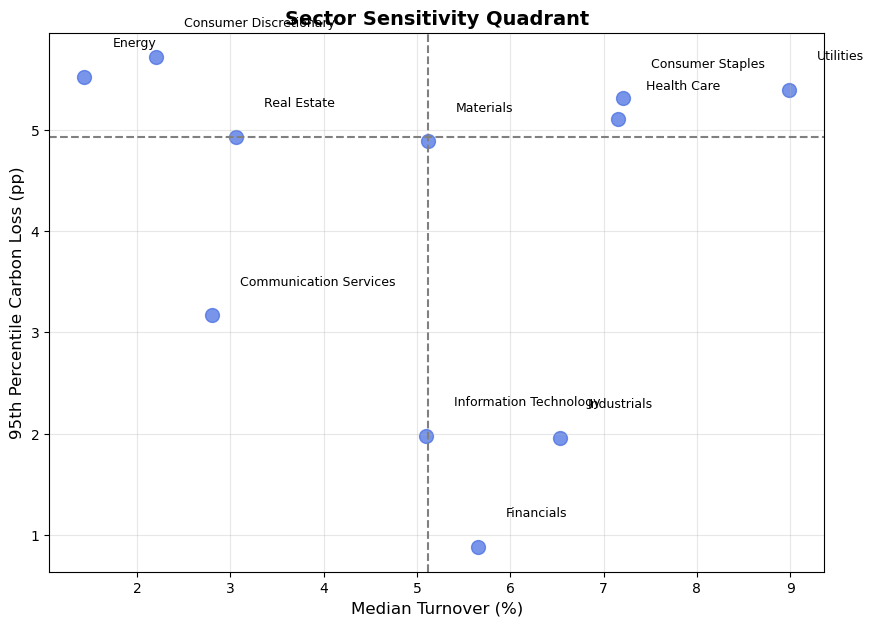

In [21]:

# Your sensitivity data

# Extract values
sectors = list(sensitivity_results.keys())
x = [sensitivity_results[s]['Median_Turnover_pct'] for s in sectors]
y = [sensitivity_results[s]['P95_CarbonLoss_pp'] for s in sectors]

# Calculate medians to define quadrant boundaries
x_med = np.median(x)
y_med = np.median(y)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(x, y, s=100, color="royalblue", alpha=0.7)

# Add labels
for i, sector in enumerate(sectors):
    plt.text(x[i]+0.3, y[i]+0.3, sector, fontsize=9)

# Quadrant lines
plt.axvline(x=x_med, color="grey", linestyle="--")
plt.axhline(y=y_med, color="grey", linestyle="--")

# Titles and labels
plt.title("Sector Sensitivity Quadrant", fontsize=14, fontweight="bold")
plt.xlabel("Median Turnover (%)", fontsize=12)
plt.ylabel("95th Percentile Carbon Loss (pp)", fontsize=12)

# Axis grid
plt.grid(alpha=0.3)

plt.show()


In [22]:
for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_1221.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    check_total_variability(R_clean, sector_name)

Consumer Discretionary: Avg Std Dev = 0.1410
Health Care: Avg Std Dev = 0.0869
Utilities: Avg Std Dev = 0.0734
Information Technology: Avg Std Dev = 0.0953
Real Estate: Avg Std Dev = 0.0959
Materials: Avg Std Dev = 0.0969
Industrials: Avg Std Dev = 0.0956
Financials: Avg Std Dev = 0.1007
Energy: Avg Std Dev = 0.2015
Communication Services: Avg Std Dev = 0.1012
Consumer Staples: Avg Std Dev = 0.0711


In [23]:
# sectors = list(sector_weights.keys())
# cond_raws = [sector_weights[s]["cond_raw"] for s in sectors]
# cond_regs = [sector_weights[s]["cond_reg"] for s in sectors]
# for s in sectors:
#     print(s, sector_weights[s]["cond_raw"])

# x = np.arange(len(sectors))

# fig, ax = plt.subplots(figsize=(12, 5))
# ax.bar(x - width / 2, cond_raws, width, label='Raw', color='tomato')
# ax.bar(x + width / 2, cond_regs, width, label='Regularized', color='seagreen')

# ax.set_yscale('log')  # <--- ADD THIS

# ax.set_xticks(x)
# ax.set_xticklabels(sectors, rotation=45, ha='right')
# ax.set_ylabel("Condition Number (log scale)")
# ax.set_title("Covariance Matrix Condition Numbers by Sector")
# ax.legend()
# ax.grid(True, axis='y')
# plt.tight_layout()
# plt.show()


In general all sectors are severely ill-conditioned, except for the Energy and Communication Services sectors that are mildy ill-conditioned.  What could be the reason why Energy condition number is lower?
Maybe because narrow spread of correlation (tigh around 0.6-0.9) can sometimes reduce spread in eigenvalues.
For communication services, it may be simply because of the low number of constituents. 

In [24]:

# def sigma_raw_fn(R_clean):
#     return R_clean.cov()

# def sigma_reg_fn(R_clean):
#     lw = LedoitWolf().fit(R_clean)
#     Sigma_shrink = lw.covariance_
#     lambda_I = 1e-5
#     return Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])

# for sector_name in data['GICS Sector'].unique():
#     R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_1221.xlsx", sheet_name=sector_name)
#     R_clean = R.drop(columns=['Date']).dropna()
#     Sigma_raw = sigma_raw_fn(R_clean)
#     Sigma_reg = sigma_reg_fn(R_clean)
#     eigvals_raw = np.linalg.eigvalsh(Sigma_raw)
#     eigvals_reg = np.linalg.eigvalsh(Sigma_reg)

#     # Combine eigenvalues to get common x-axis range
#     all_eigvals = np.concatenate([eigvals_raw, eigvals_reg])
#     xmin, xmax = np.min(all_eigvals), np.max(all_eigvals)
#     bins = np.linspace(xmin, xmax, 30)

#     fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#     fig.suptitle(f"Eigenvalue Spectrum – {sector_name}", fontsize=16)

#     # Raw
#     axes[0].hist(eigvals_raw, bins=bins, alpha=0.7, color='tomato', edgecolor='black')
#     axes[0].set_title("Raw Covariance")
#     axes[0].set_xlabel("Eigenvalue")
#     axes[0].set_ylabel("Frequency")
#     axes[0].grid(True)
#     axes[0].set_xlim(xmin, xmax)
#     print(f"min: {eigvals_raw.min():.2e}")
#     print(f"max: {eigvals_raw.max():.2e}")
#     print(f"Condition number: {eigvals_raw.max()/eigvals_raw.min():.2e}")
#     cond_number = np.linalg.cond(sigma_raw_fn(R_clean))
#     print(f"{cond_number:.2e}")
#     # Annotate min and max eigenvalues
#     axes[0].annotate(f"min: {eigvals_raw.min():.2e}", xy=(eigvals_raw.min(), 1), xytext=(eigvals_raw.min(), 3),
#                      arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')
#     axes[0].annotate(f"max: {eigvals_raw.max():.2e}", xy=(eigvals_raw.max(), 1), xytext=(eigvals_raw.max(), 3),
#                      arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')

#     # Regularized
#     axes[1].hist(eigvals_reg, bins=bins, alpha=0.7, color='seagreen', edgecolor='black')
#     axes[1].set_title("Regularized Covariance")
#     axes[1].set_xlabel("Eigenvalue")
#     axes[1].grid(True)
#     axes[1].set_xlim(xmin, xmax)

#     # Annotate min and max eigenvalues
#     axes[1].annotate(f"min: {eigvals_reg.min():.2e}", xy=(eigvals_reg.min(), 1), xytext=(eigvals_reg.min(), 3),
#                      arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')
#     axes[1].annotate(f"max: {eigvals_reg.max():.2e}", xy=(eigvals_reg.max(), 1), xytext=(eigvals_reg.max(), 3),
#                      arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')

#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()


The max eigenvalue gets pulled down toward the average variance, so better conditioning is achieved.

A low condition number is good because:

- It means the matrix is well-conditioned
- The matrix is invertible
- Portfolio weights are less sensitive to estimation noise
- Optimization becomes more robust

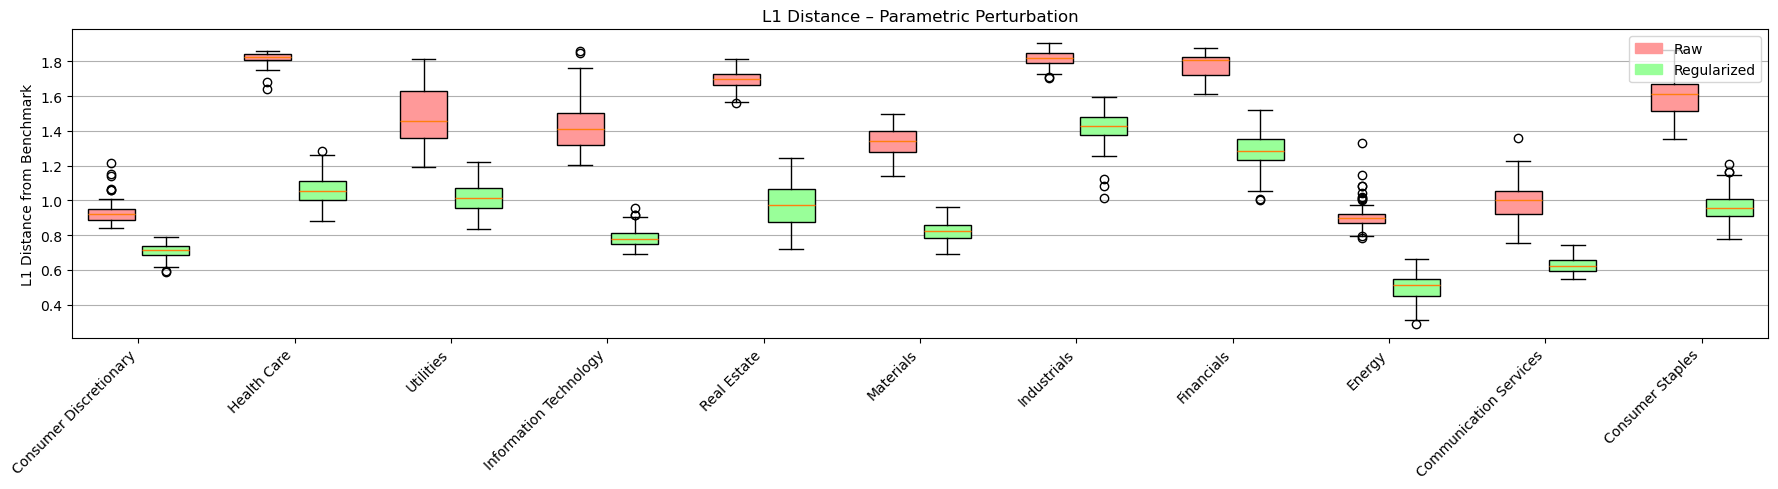

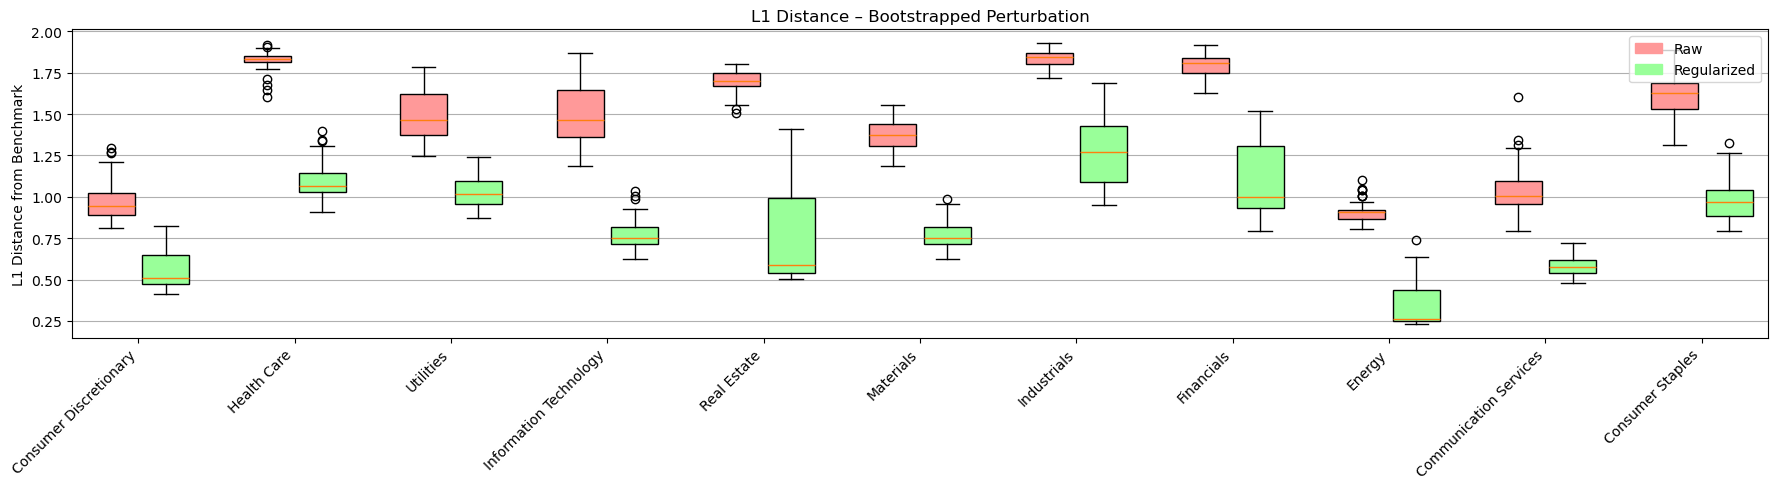

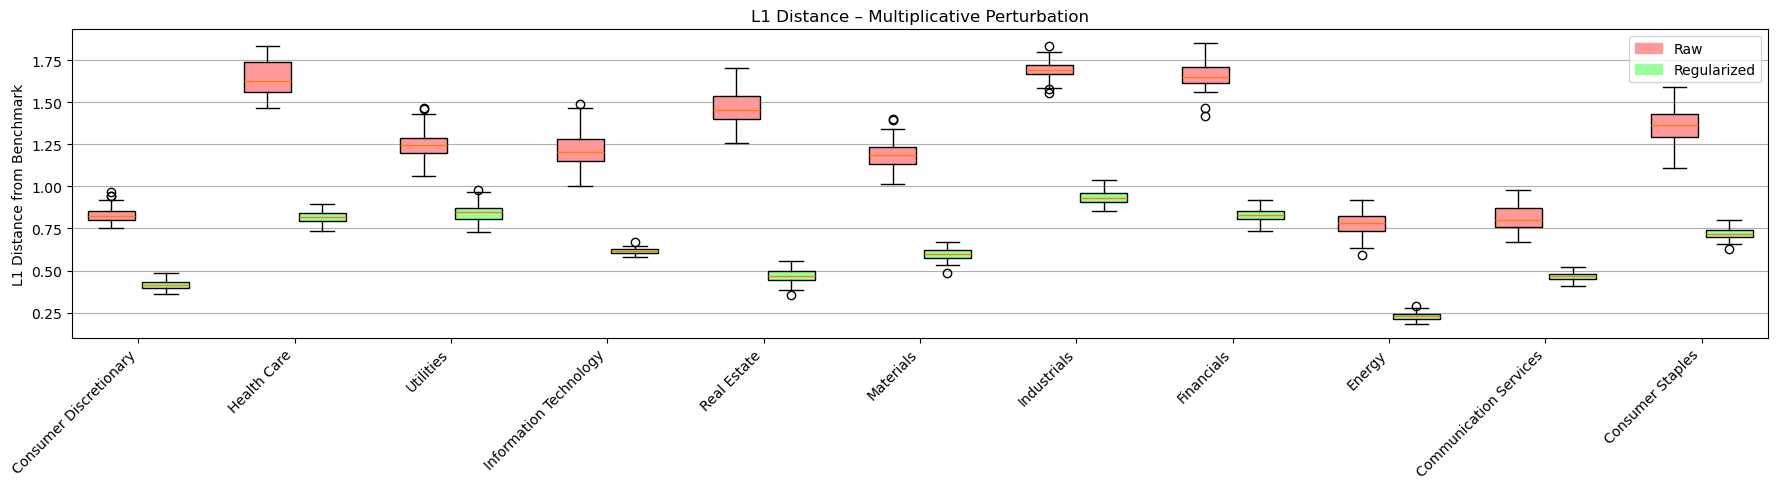

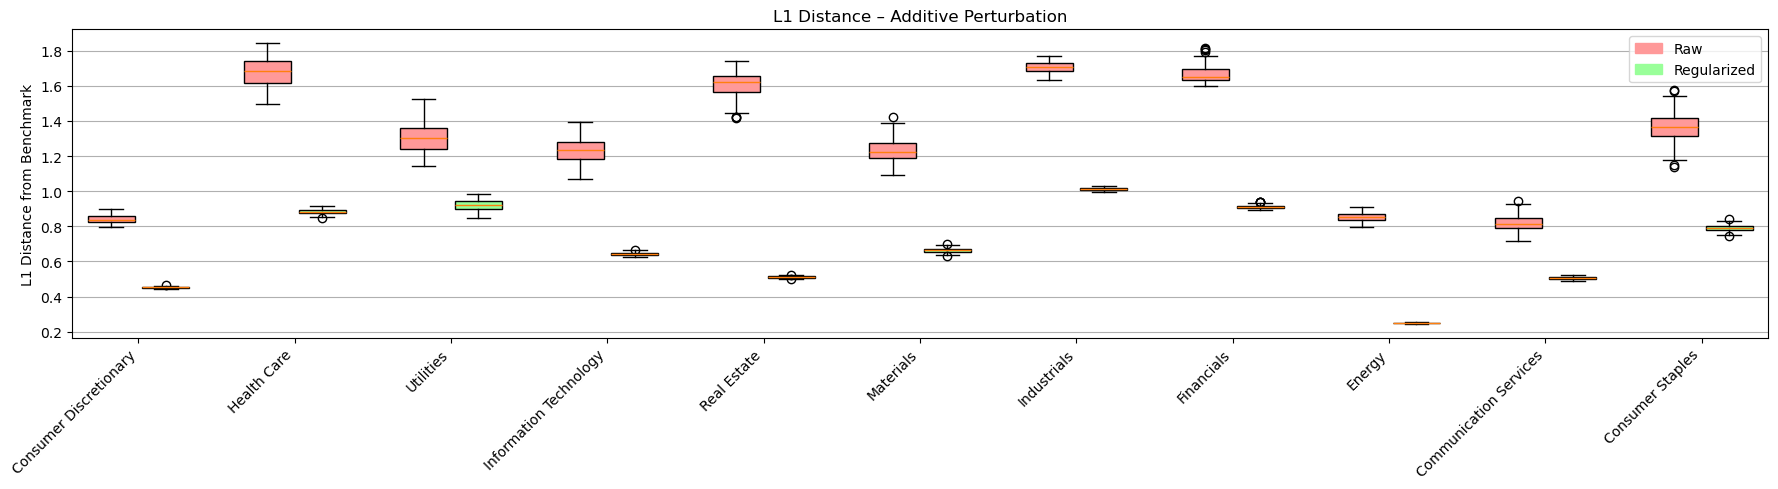

In [25]:
def plot_l1_boxplot(sector_weights, sectors, noise_type, title):
    fig, ax = plt.subplots(figsize=(18, 5))
    positions = []
    data = []
    colors = []
    labels = []

    for i, sector in enumerate(sectors):
        data.extend([
            sector_weights[sector][f"l1_{noise_type}_raw"],
            sector_weights[sector][f"l1_{noise_type}_reg"]
        ])
        positions.extend([2 * i, 2 * i + 0.7])
        colors.extend(['#FF9999', '#99FF99'])
        labels.extend([f"{sector}\nRaw", "Reg"])

    box = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    # X-axis formatting
    ax.set_xticks([2 * i + 0.35 for i in range(len(sectors))])
    ax.set_xticklabels(sectors, rotation=45, ha='right')

    # Labels & title
    ax.set_title(f"L1 Distance – {title}")
    ax.set_ylabel("L1 Distance from Benchmark")
    ax.grid(True, axis='y')

    # Legend
    legend_patches = [
        Patch(color='#FF9999', label='Raw'),
        Patch(color='#99FF99', label='Regularized')
    ]
    ax.legend(handles=legend_patches, loc='upper right')

    plt.tight_layout()
    plt.show()

# Usage
sectors = list(sector_weights.keys())
# Captures joint distribution if estimation is accurate
plot_l1_boxplot(sector_weights, sectors, noise_type="param", title="Parametric Perturbation")
# Non-parametric, respects empirical distribution
plot_l1_boxplot(sector_weights, sectors, noise_type="boot", title="Bootstrapped Perturbation")
# Noise is return-scaled, but not volatility-aware
plot_l1_boxplot(sector_weights, sectors, noise_type="mult", title="Multiplicative Perturbation")
# Adds uniform noise regardless of asset properties
plot_l1_boxplot(sector_weights, sectors, noise_type="add", title="Additive Perturbation")



In [26]:
# # Load dataset to count stocks per sector
# data = pd.read_excel("Data/out-of-sample/dataset_comp_1221.xlsx")

# # Count number of stocks per sector
# sector_stock_counts = {
#     sector: data[data['GICS Sector'] == sector]['SYMBOL'].nunique()
#     for sector in data['GICS Sector'].unique()
# }

# # Sort sectors by number of stocks descending
# sorted_sectors = sorted(sector_stock_counts.items(), key=lambda x: x[1], reverse=True)

# # Loop through sorted sectors
# for sector_name, _ in sorted_sectors:
#     # Load returns
#     R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_1221.xlsx", sheet_name=sector_name)
#     R_clean = R.drop(columns=['Date']).dropna()

#     # Compute correlation matrix
#     corr_matrix = R_clean.corr()

#     # Use seaborn clustermap with hierarchical clustering
#     g = sns.clustermap(
#         corr_matrix,
#         method='average',           # you can try 'complete', 'ward', etc.
#         metric='correlation',       # distance = 1 - corr
#         cmap='coolwarm',
#         center=0,
#         vmin=-1, vmax=1,
#         figsize=(12, 10)
#     )

#     # Set title
#     g.fig.suptitle(f"Hierarchical Clustering – {sector_name}", y=1.02)

#     plt.show()


Lower correlation means better diversification and so the overall portfolio risk can be reduce. However, excessively low correlations may be a sign of modeling noise and on the other hand, if secors have high correlations but uniform then the covariance matrix might be less fragile. In fact if we look at what happens after shrinking the covariance matrix for the Energy sector (a sector with strong and uniform correlations) the L1 distance boxplot was already narrow before the regularisation and keeps the same length after regularisation. While for Communication Services a sector with lower correlations, the shrinkage narrowes significantly the L1 distance boxplot, meaning that the inputs sensitivity is reduced. 

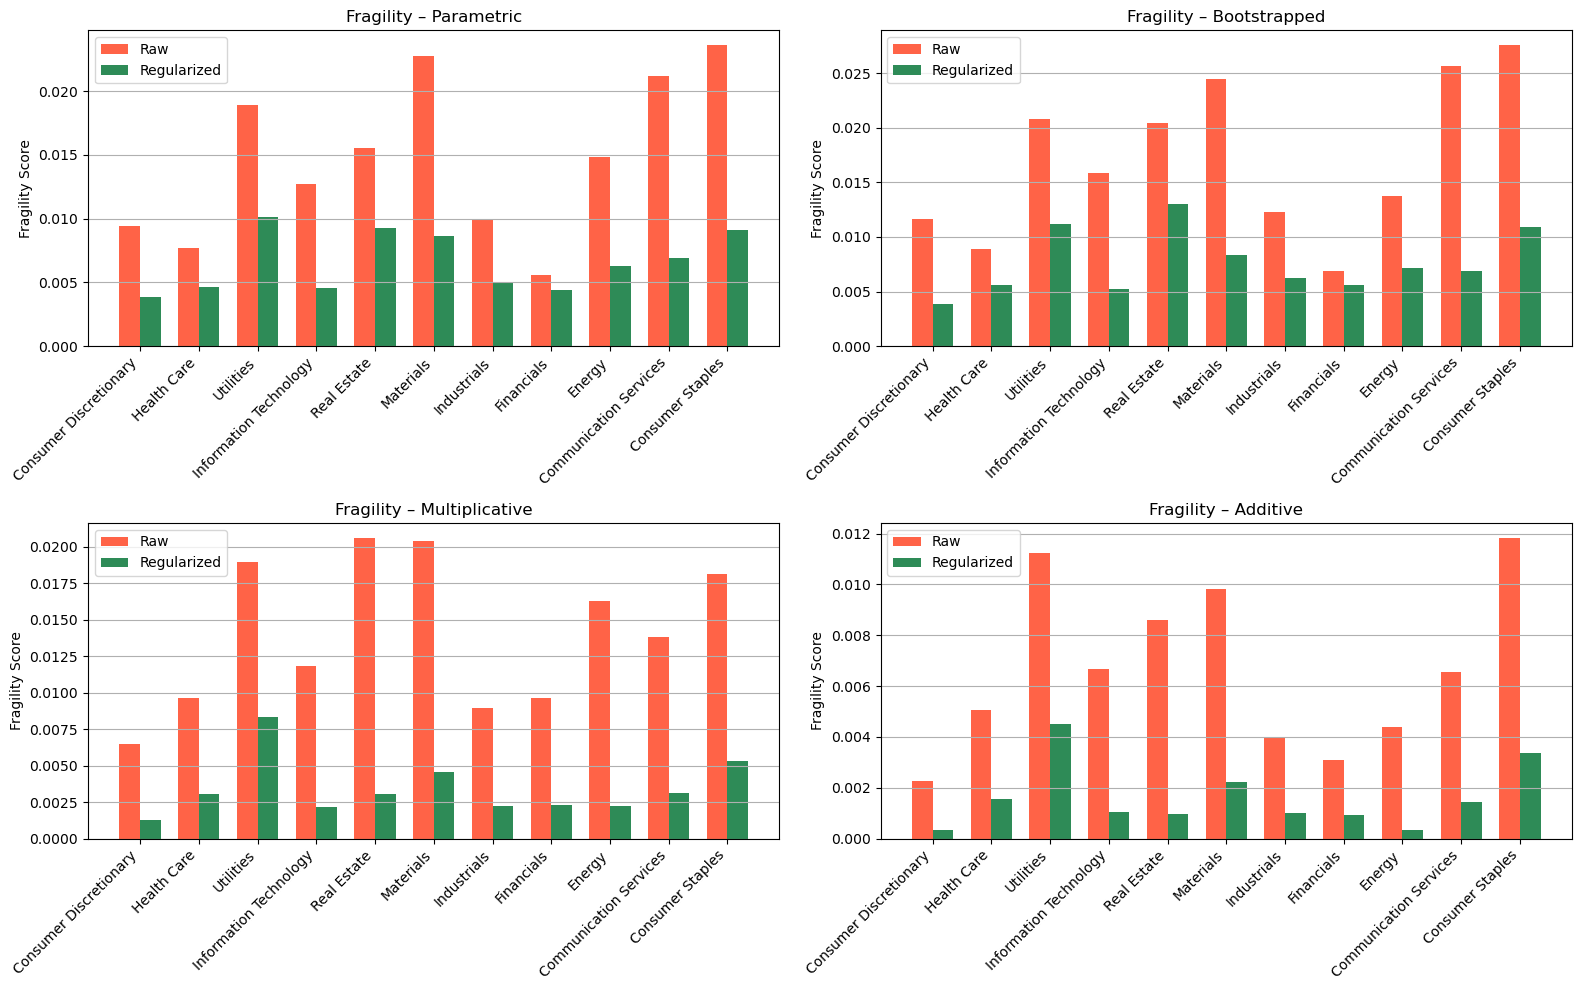

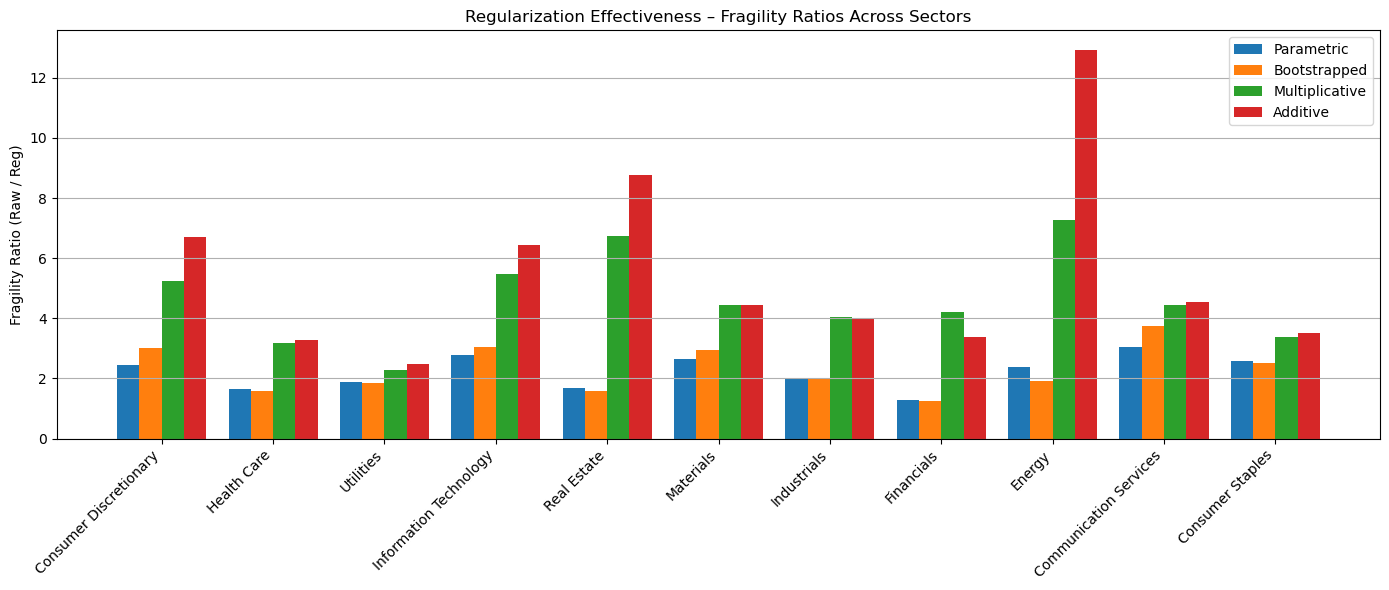

In [27]:
frag_raw_all = {"param": [], "boot": [], "mult": [], "add": []}
frag_reg_all = {"param": [], "boot": [], "mult": [], "add": []}
frag_ratio_all = {"param": [], "boot": [], "mult": [], "add": []}

sectors = list(sector_weights.keys())
for sector in sectors:
    for noise_type in ["param", "boot", "mult", "add"]:
        frag_raw_all[noise_type].append(sector_weights[sector][f"frag_{noise_type}_raw"])
        frag_reg_all[noise_type].append(sector_weights[sector][f"frag_{noise_type}_reg"])
        frag_ratio_all[noise_type].append(sector_weights[sector][f"frag_ratio_{noise_type}"])

# Plot Fragility (Raw vs Reg)
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
noise_labels = ["param", "boot", "mult", "add"]
titles = ["Parametric", "Bootstrapped", "Multiplicative", "Additive"]

for i, noise_type in enumerate(noise_labels):
    ax = axs[i // 2, i % 2]
    x = np.arange(len(sectors))
    width = 0.35

    ax.bar(x - width/2, frag_raw_all[noise_type], width, label='Raw', color='tomato')
    ax.bar(x + width/2, frag_reg_all[noise_type], width, label='Regularized', color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.set_ylabel("Fragility Score")
    ax.set_title(f"Fragility – {titles[i]}")
    ax.legend()
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

# Plot Fragility Ratios
fig, ax = plt.subplots(figsize=(14, 6))

width = 0.2
x = np.arange(len(sectors))

for i, noise_type in enumerate(noise_labels):
    offset = (i - 1.5) * width
    ax.bar(x + offset, frag_ratio_all[noise_type], width, label=titles[i])

ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=45, ha='right')
ax.set_ylabel("Fragility Ratio (Raw / Reg)")
ax.set_title("Regularization Effectiveness – Fragility Ratios Across Sectors")
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

So what happens for Consumer Staples?
1. Regularization shrinks the weight variability
- Each individual asset weight is more tightly concentrated across trials. That means fragility (weight-level std deviation) is lower.

2. But it may allow small, coordinated shifts away from benchmark
- Those smaller deviations may consistently be in different directions across trials. So while the overall size of deviation is small, the L1 distance from benchmark still varies more.

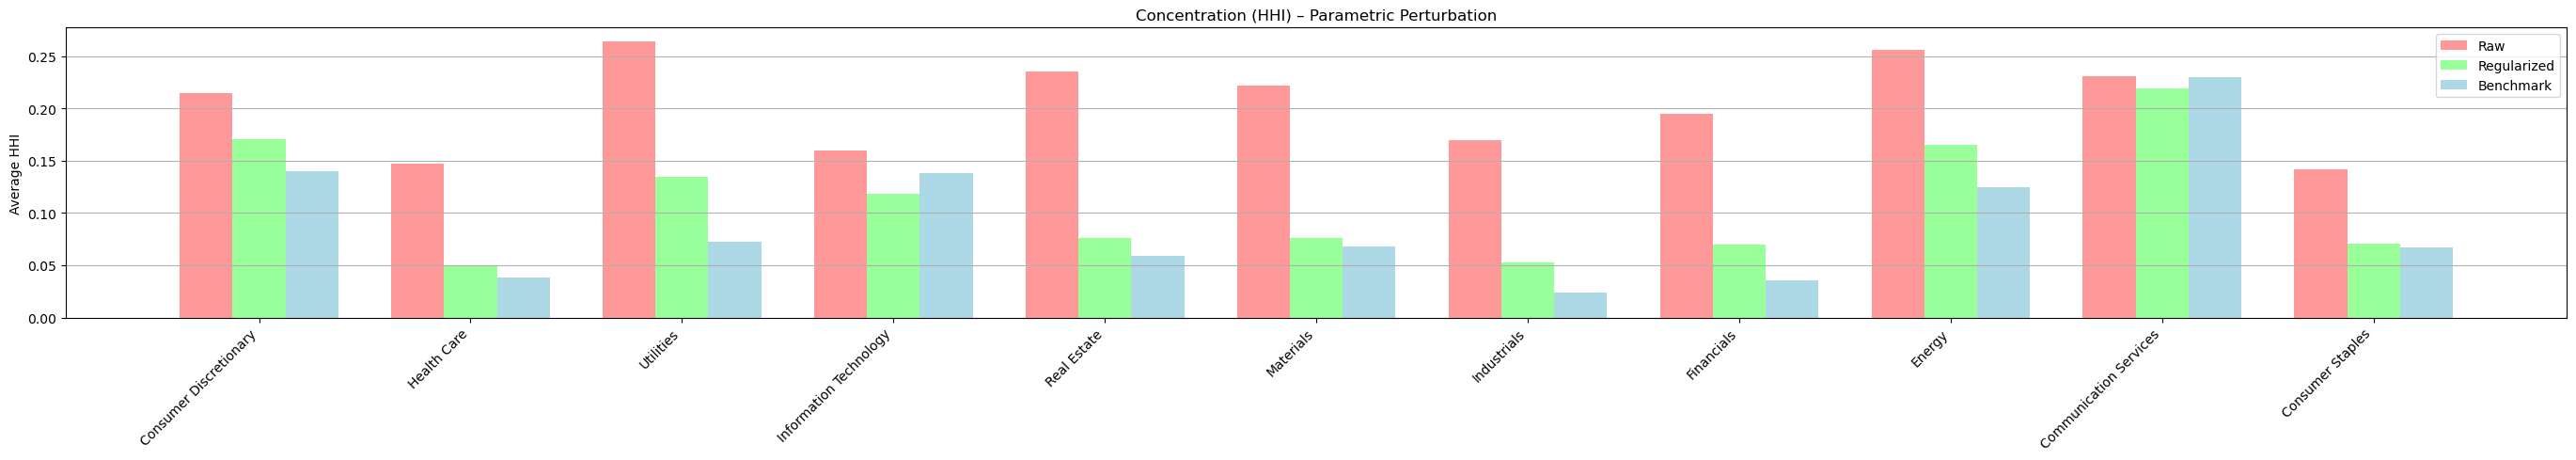

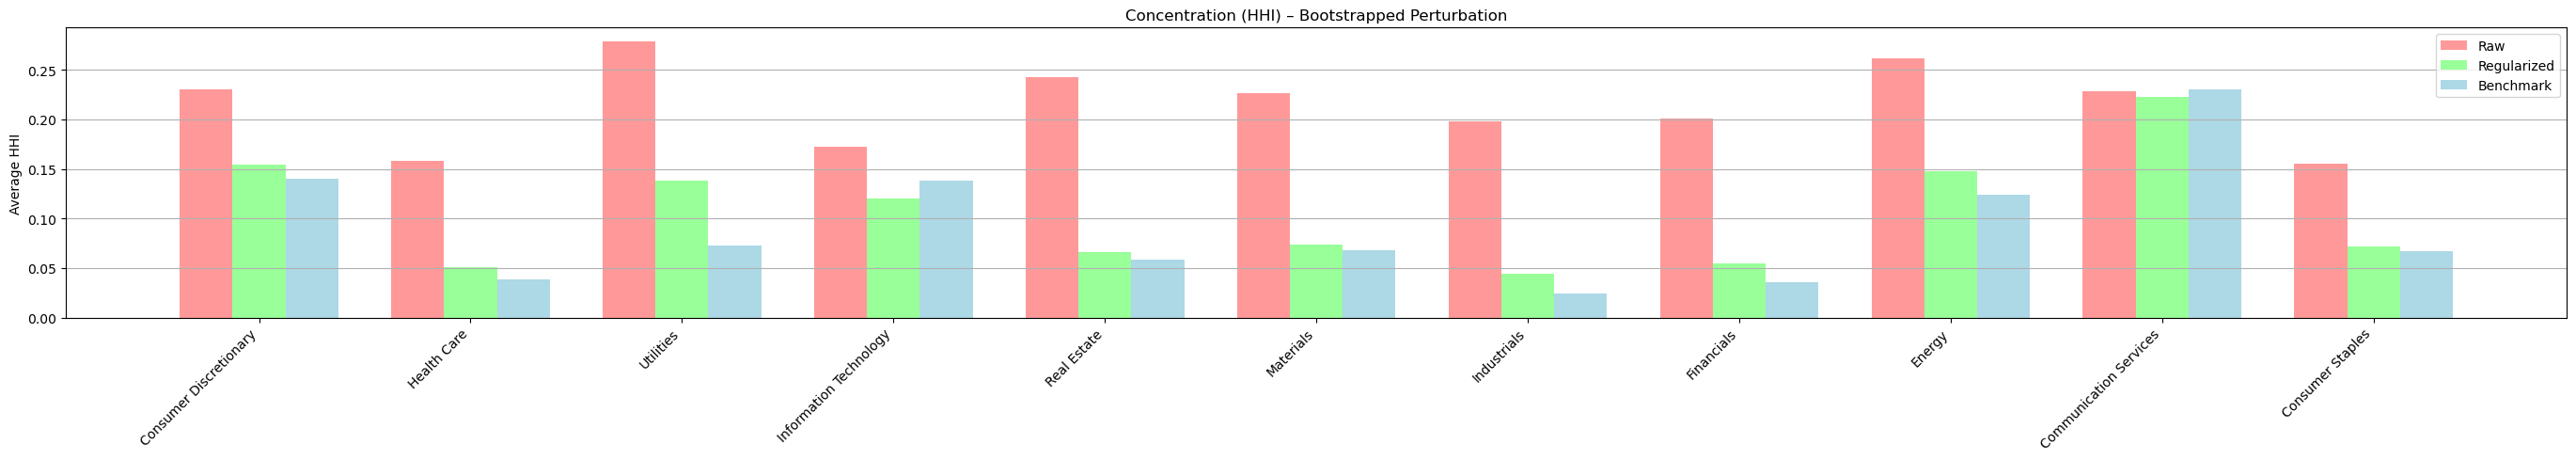

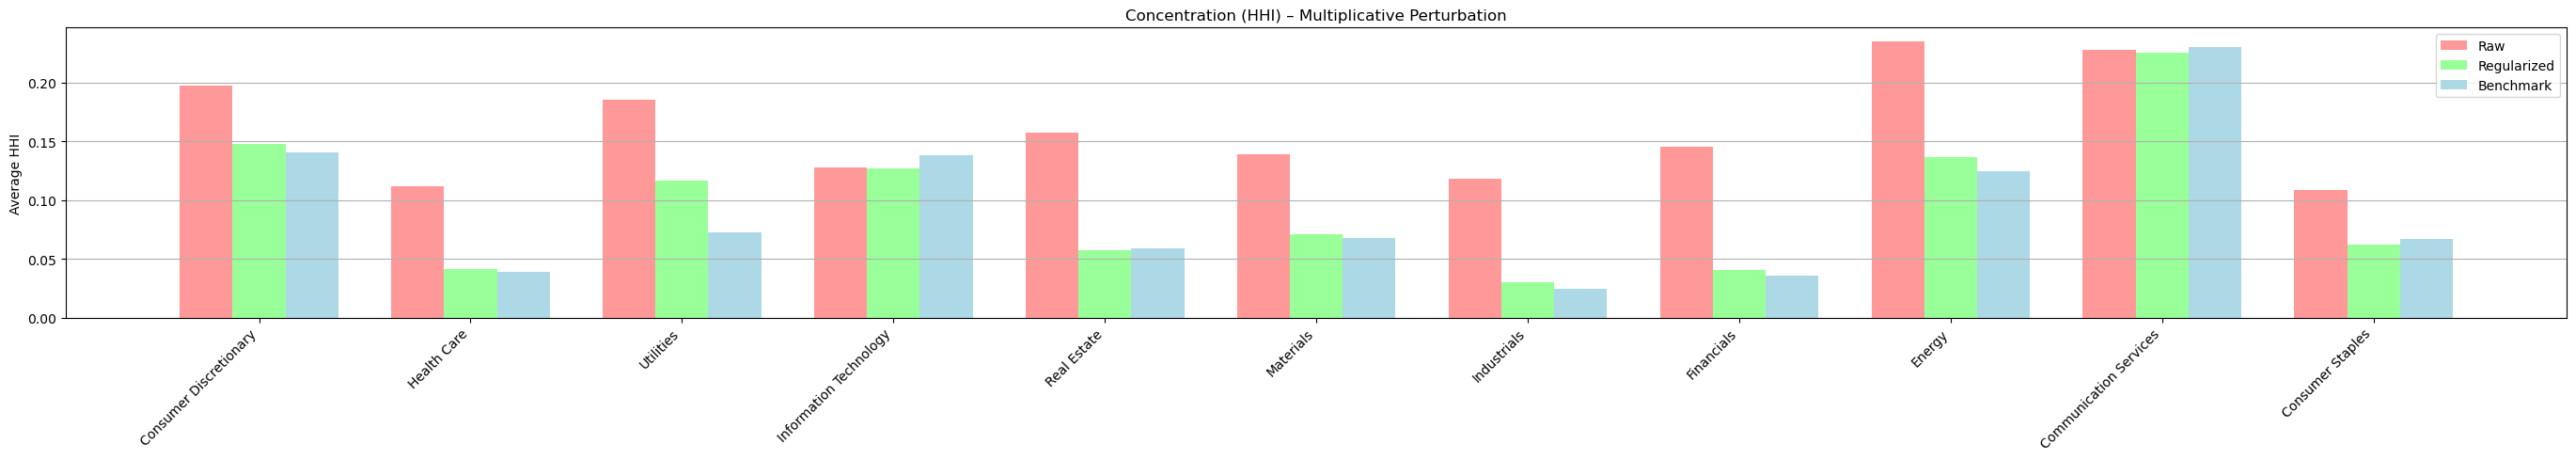

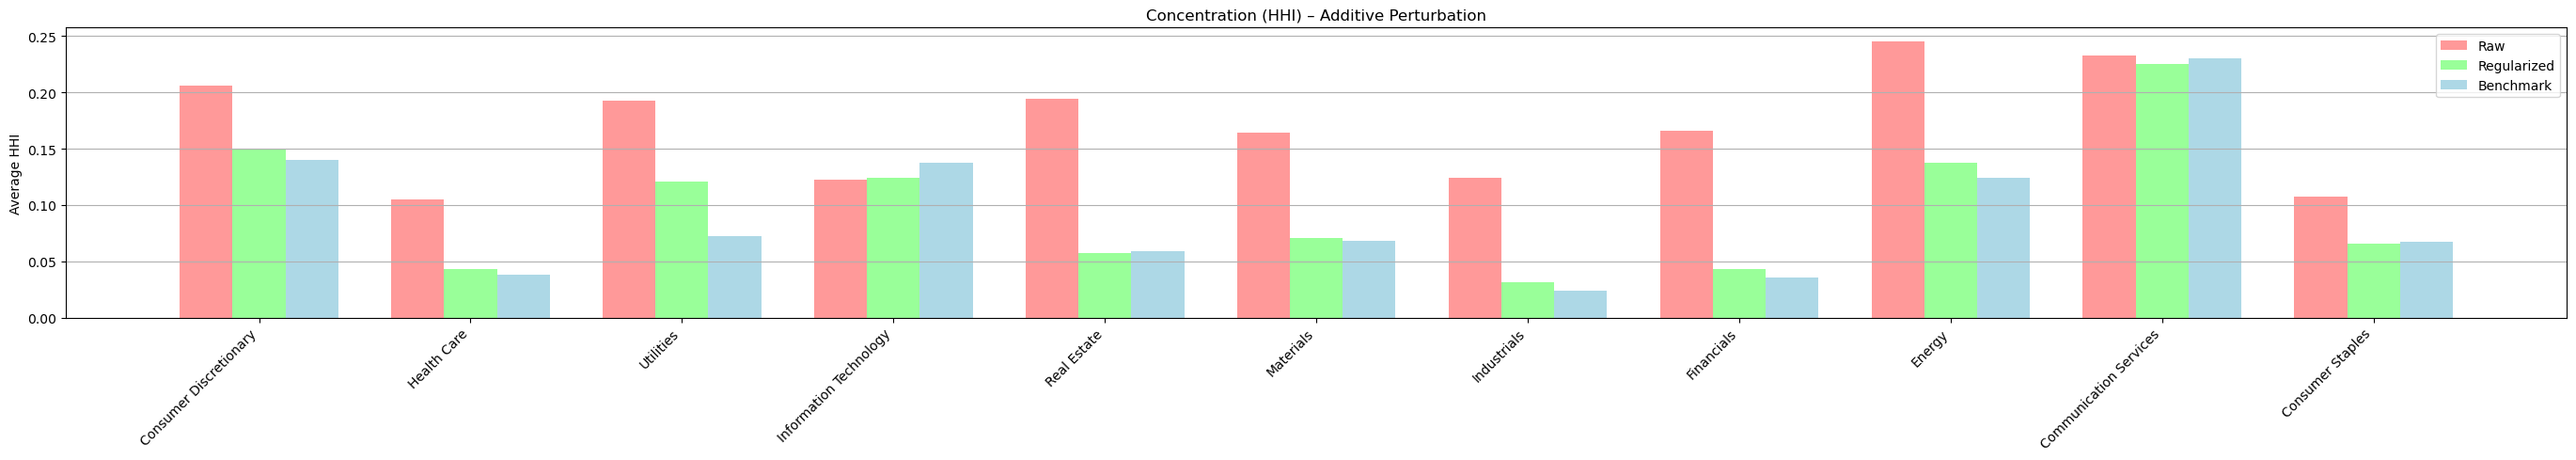

In [28]:
def plot_hhi_bars(sector_weights, sectors, noise_type, title):
    hhi_raw = []
    hhi_reg = []
    hhi_benchmark = []

    for sector in sectors:
        hhi_raw.append(sector_weights[sector][f"hhi_{noise_type}_raw"])
        hhi_reg.append(sector_weights[sector][f"hhi_{noise_type}_reg"])
        hhi_benchmark.append(sector_weights[sector]["hhi_benchmark"])

    x = np.arange(len(sectors))
    width = 0.25  # Narrower to fit 3 bars

    fig, ax = plt.subplots(figsize=(2.5 * len(sectors), 5))

    ax.bar(x - width, hhi_raw, width, label='Raw', color='#FF9999')
    ax.bar(x, hhi_reg, width, label='Regularized', color='#99FF99')
    ax.bar(x + width, hhi_benchmark, width, label='Benchmark', color='#ADD8E6')

    ax.set_xticks(x)
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.set_ylabel("Average HHI")
    ax.set_title(f"Concentration (HHI) – {title}")
    ax.legend()
    ax.grid(True, axis='y')

    plt.tight_layout()
    plt.show()

sectors = list(sector_weights.keys())

plot_hhi_bars(sector_weights, sectors, noise_type="param", title="Parametric Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="boot", title="Bootstrapped Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="mult", title="Multiplicative Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="add", title="Additive Perturbation")

In [29]:
optimal_portfolios_shrink_2_TE['Consumer Discretionary']

{'cov_type': 'shrink',
 'diagnostics': {'Sector': 'Consumer Discretionary',
  'Num Features': 56,
  'Covariance': 'shrink',
  'Rank': 56,
  'Min_Eigval1': 0.009586630754109376,
  'Min_Eigval2': 0.009586630754109388,
  'Min_Eigval3': 0.009586630754109399,
  'Low Rank?': False,
  'Not PSD?': False,
  'Shrinkage Alpha': 0.41863458898712935,
  'Start Reduction (%)': 6.67,
  'End Reduction (%)': 74.84,
  'Gain (%)': 68.18,
  'Reduction @2% TE (%)': 52.06},
 'w_opt': array([3.07942650e-01, 1.61418820e-02, 4.90542542e-03, 1.26552214e-09,
        1.01932994e-02, 2.47959866e-09, 1.17579340e-02, 4.54062212e-08,
        1.14658984e-02, 1.14039178e-03, 1.01419122e-02, 1.02844738e-02,
        1.02910494e-01, 4.03808374e-03, 1.99866537e-08, 2.12300689e-02,
        7.85517758e-03, 8.05798259e-03, 1.90235147e-08, 2.33401303e-04,
        6.42202435e-03, 4.89473775e-02, 2.03154776e-03, 2.72455182e-07,
        1.23387895e-02, 8.02300257e-04, 6.63054921e-03, 5.64566546e-03,
        2.70032643e-02, 3.62794

In [30]:
def compute_hhi(weights):
    """Herfindahl–Hirschman Index (HHI) for concentration."""
    weights = np.array(weights)
    return np.sum(weights ** 2)

# Prepare results dict
for sector_name, sector_data in optimal_portfolios_shrink_2_TE.items():

    # === Construct DataFrames for benchmark and optimized portfolios ===
    symbols = sector_data["stock_labels"]
    w_bench = sector_data["w_bench"]
    w_opt = sector_data["w_opt"]

    benchmark_df = pd.DataFrame({"symbol": symbols, "w": w_bench}).sort_values(by="w", ascending=False)
    optimised_df = pd.DataFrame({"symbol": symbols, "w": w_opt}).sort_values(by="w", ascending=False)

    # === Top overlap metrics ===
    optimal_portfolios_shrink_2_TE[sector_name].update({
        "count_1": 1 if benchmark_df["symbol"].iloc[0] == optimised_df["symbol"].iloc[0] else 0,
        "count_3": len(set(benchmark_df["symbol"].iloc[:3]) & set(optimised_df["symbol"].iloc[:3])),
        "count_5": len(set(benchmark_df["symbol"].iloc[:5]) & set(optimised_df["symbol"].iloc[:5])),
        "count_10": len(set(benchmark_df["symbol"].iloc[:10]) & set(optimised_df["symbol"].iloc[:10])),
    })

    # === Sparsity metrics ===
    zero_count = (optimised_df["w"] < 1e-4).sum()
    zero_pct = zero_count / len(optimised_df)

    optimal_portfolios_shrink_2_TE[sector_name].update({
        "zero_stocks": zero_count,
        "zero_stocks_%": zero_pct
    })

    # === HHI (portfolio concentration) ===
    hhi_bench = compute_hhi(w_bench)
    hhi_opt = compute_hhi(w_opt)
    optimal_portfolios_shrink_2_TE[sector_name].update({
        "hhi_benchmark_portfolio": hhi_bench,
        "hhi_optimised_portfolio": hhi_opt
    })

    # === % Carbon reduction ===
    # Already stored in your dict as "carbon_reduction_at_2pct"
    optimal_portfolios_shrink_2_TE[sector_name].update({
        "% carbon reduction": sector_data["carbon_reduction_at_2pct"]
    })

# === Summarize results into a DataFrame ===
print("\nSummary of Optimal Portfolio Diagnostics by Sector (TE = 2%):\n")

columns = [
    "count_1", "count_3", "count_5", "count_10",
    "zero_stocks", "zero_stocks_%",
    "hhi_benchmark_portfolio", "hhi_optimised_portfolio",
    "% carbon reduction"
]

summary_data = []
for sector_name, info in optimal_portfolios_shrink_2_TE.items():
    row = [sector_name] + [info.get(col, np.nan) for col in columns]
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data, columns=["Sector"] + columns).set_index("Sector")

# Format and sort
summary_df["zero_stocks_%"] = summary_df["zero_stocks_%"].apply(lambda x: f"{x:.2%}")
summary_df["% carbon reduction"] = summary_df["% carbon reduction"].apply(lambda x: f"{x:.2f}%")

print(summary_df.sort_values(by="zero_stocks_%", ascending=False))





Summary of Optimal Portfolio Diagnostics by Sector (TE = 2%):

                        count_1  count_3  count_5  count_10  zero_stocks  \
Sector                                                                     
Real Estate                   1        3        5         8            2   
Information Technology        1        3        5         7           34   
Energy                        1        3        4         8            1   
Industrials                   0        1        3         6           24   
Utilities                     1        1        2         5            9   
Financials                    1        2        4         7           23   
Health Care                   1        2        3         7           17   
Communication Services        1        2        4         7            6   
Consumer Discretionary        1        3        4         8           12   
Consumer Staples              0        2        3         8            6   
Materials               

In the Financials sector, there are few top 10 stocks in common with the benchmark, and a high percentage of stocks are assigned zero weight. This may be because the top 10 companies in this sector are too carbon-intensive, and with a 2% tracking error constraint, the optimiser can still allow relatively high carbon intensity. This is especially true because the sector has a large number of constituents and is not very concentrated.

In contrast, in highly concentrated sectors that have high or medium carbon intensity in their top 10 stocks, I expect the optimiser to achieve only a modest carbon reduction. That’s the case for Communication Services, which has only 22 stocks — the most concentrated sector — and therefore achieves a relatively low carbon reduction (only 20%).

But there are also cases like Consumer Discretionary, where the concentration is relatively high (HHI ≈ 0.11), yet the optimiser achieves a significant carbon reduction of 73%. This might be because the top 10 companies in that sector already have relatively low carbon intensity.

In the case of Materials, the percentage of stocks with zero weight is the lowest across all sectors. This could be because, given the sector’s low concentration, the optimiser needs to retain most of the constituents to stay close to the benchmark. Excluding too many companies would increase the tracking error — especially since the sector already has a small number of stocks (29)